# Canonical Correlation Analysis (CCA) for Neural Data

This notebook performs CCA to assess correlations between different brain areas during different task epochs, following a PCA-CCA pipeline with bootstrap testing and subspace comparison.

## 1. Import Required Libraries

In [2]:
import pandas as pd
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.cross_decomposition import CCA

# For data loading from existing pipeline
import npc_lims
from dynamic_routing_analysis import spike_utils
from dynamic_routing_analysis import data_utils

%load_ext autoreload
%autoreload 2

## 2. Load and Prepare Neural Data

In [3]:
# Load session data
# session_id = "664851_2023-11-13"  # mediocre DR session 
session_id = "742903_2024-10-22"  # good DR session 

session_info = npc_lims.get_session_info(session_id)
trials = data_utils.load_trials_or_units(session_info, 'trials', version='0.0.272')
units = data_utils.load_trials_or_units(session_info, 'units', version='0.0.272')

# Filter units with quality criteria
units_filtered = units.query(
    'presence_ratio>=0.7 and \
    isi_violations_ratio<=0.5 and \
    amplitude_cutoff<=0.1 and \
    activity_drift<=0.2 and \
    firing_rate>=0.5 and \
    ~structure.isna() and ~location.isna()'
).sort_values(['electrode_group_name', 'peak_channel', 'unit_id'])

print(f"Total filtered units: {len(units_filtered)}")
print(f"Structures represented: {units_filtered['structure'].unique()}")

742903_2024-10-22 cached trials loaded
742903_2024-10-22 cached units loaded
Total filtered units: 1442
Structures represented: ['LSr' 'ACAv' 'PL' 'ACAd' 'MOs' 'out of brain' 'GU' 'SSs' 'SSp' 'CP' 'CA3'
 'DG' 'CA1' 'VISal' 'TTd' 'ORBvl' 'OLF' 'ORBl' 'FRP' 'ILA' 'ORBm']


In [4]:
# Create trial data arrays for task epochs
time_before = 0.5
time_after = 0.01
binsize = 0.5

trial_da = spike_utils.make_neuron_time_trials_tensor(
    units_filtered, trials, time_before, time_after, binsize
)

print(f"Task trial data shape: {trial_da.shape}")
print(f"Dimensions: {trial_da.dims}")

Task trial data shape: (1442, 1, 538)
Dimensions: ('unit_id', 'time', 'trials')


In [5]:
# Load spontaneous data (from existing notebook logic)
epochs = pd.read_parquet(
    npc_lims.get_cache_path(nwb_component='epochs', session_id=session_id, version='0.0.272')
)

# Load rewards for spontaneous trial alignment
import lazynwb
path = 's3://aind-scratch-data/dynamic-routing/cache/nwb/v0.0.272/{session_id}.nwb'
internal_path = 'processing/behavior/rewards'
rewards = lazynwb.get_df(path.format(session_id=session_id), internal_path, as_polars=False)

print(f"Epochs available: {epochs['script_name'].unique()}")

Epochs available: ['RFMapping' 'OptoTagging' 'Spontaneous' 'SpontaneousRewards'
 'DynamicRouting1']


In [6]:
# Generate spontaneous trials using ITI distribution
def generate_DR_ITI(n_samples=None, is_templeton=False):
    import random
    
    preStimFramesFixed = 90
    preStimFramesVariableMean = 60
    preStimFramesMax = 360
    responseWindow = [6, 60]
    postResponseWindowFrames = 180
    
    if is_templeton:
        preStimFramesVariableMean = 30
        preStimFramesMax = 240
        postResponseWindowFrames = 120
    
    if n_samples is not None:
        return [generate_DR_ITI(is_templeton=is_templeton) for _ in range(n_samples)]
    else:
        val = preStimFramesFixed + random.expovariate(1/preStimFramesVariableMean) if preStimFramesVariableMean > 1 else preStimFramesFixed + preStimFramesVariableMean
        trial_total_length = (int(min(val, preStimFramesMax)) + responseWindow[1] + postResponseWindowFrames) / 60
        return trial_total_length

# Create spontaneous trial times
min_ITI = 5.5
spont_trials = {
    'start_time': [],
    'epoch_idx': [],
    'epoch_name': [],
    'is_rewarded': []
}

task_index=epochs.query('script_name=="DynamicRouting1"').index[0]

for rr, row in epochs.query('script_name=="Spontaneous" and id<@task_index').iterrows():
# for rr, row in epochs.query('script_name.str.contains("Spontaneous")').iterrows():
    spont_start = row['start_time']
    spont_end = row['stop_time']
    
    sampleITIs = generate_DR_ITI(n_samples=1000, is_templeton=False)
    cum_sampleITIs = np.cumsum(sampleITIs)
    valid_starts = spont_start + cum_sampleITIs[cum_sampleITIs + spont_start < spont_end]
    is_rewarded = np.zeros(len(valid_starts), dtype=bool)
    
    # Find rewards and align trials
    reward_times = rewards.query('timestamps>=@spont_start and timestamps<=@spont_end')['timestamps'].to_numpy()
    if len(reward_times) > 0:
        for rt in reward_times:
            incl_idx = np.abs(valid_starts - rt) > (min_ITI)
            valid_starts = valid_starts[incl_idx]
            is_rewarded = is_rewarded[incl_idx]
        valid_starts = np.concatenate([valid_starts, reward_times])
        is_rewarded = np.concatenate([is_rewarded, np.ones(len(reward_times), dtype=bool)])
    
    spont_trials['start_time'].append(valid_starts)
    spont_trials['epoch_idx'].append(np.repeat(rr, len(valid_starts)))
    spont_trials['epoch_name'].append(np.repeat(row['script_name'], len(valid_starts)))
    spont_trials['is_rewarded'].append(is_rewarded)

spont_trials['start_time'] = np.concatenate(spont_trials['start_time'])
spont_trials['epoch_idx'] = np.concatenate(spont_trials['epoch_idx'])
spont_trials['epoch_name'] = np.concatenate(spont_trials['epoch_name'])
spont_trials['is_rewarded'] = np.concatenate(spont_trials['is_rewarded'])

spont_trials_df = pd.DataFrame(spont_trials).sort_values('start_time').reset_index(drop=True)

# Create spontaneous data array
spont_trial_da = spike_utils.make_neuron_time_trials_tensor(
    units_filtered, spont_trials_df, time_before, time_after, binsize, event_name='start_time'
)

print(f"Spontaneous trial data shape: {spont_trial_da.shape}")
print(f"Number of spontaneous trials: {len(spont_trials_df)}")

Spontaneous trial data shape: (1442, 1, 91)
Number of spontaneous trials: 91


## 3. Define Helper Functions for Data Preprocessing

In [9]:
def zscore_rows(X):
    """Z-score each neuron (column) across samples (rows)."""
    scaler = StandardScaler(with_mean=True, with_std=True)
    return scaler.fit_transform(X)

def match_dims(X1_pca, X2_pca):
    """Match dimensions between two PCA-reduced datasets."""
    d = min(X1_pca.shape[1], X2_pca.shape[1])
    return X1_pca[:, :d], X2_pca[:, :d], d

def canonical_corrs(X_c, Y_c):
    """Calculate canonical correlations between paired canonical variables."""
    corrs = []
    for i in range(X_c.shape[1]):
        r = np.corrcoef(X_c[:, i], Y_c[:, i])[0, 1]
        corrs.append(r)
    return np.array(corrs)

print("Helper functions defined successfully")

Helper functions defined successfully


## 4. Apply PCA Dimensionality Reduction per Area and Epoch

In [10]:
def pca_fit_keep(X, var_thresh=0.80):
    """Fit PCA and keep enough components to reach var_thresh."""
    pca_full = PCA().fit(X)
    cumvar = np.cumsum(pca_full.explained_variance_ratio_)
    n_keep = np.searchsorted(cumvar, var_thresh) + 1
    pca = PCA(n_components=n_keep).fit(X)
    return pca, n_keep, cumvar

# Select two brain areas for CCA analysis
struct1 = 'ACAd'  # Anterior cingulate area
struct2 = 'MOs'   # Secondary motor area

print(f"Analyzing areas: {struct1} and {struct2}")

Analyzing areas: ACAd and MOs


In [126]:
# Extract and prepare task data for both areas
units_struct1 = units_filtered[units_filtered['structure'] == struct1]['unit_id'].unique()
units_struct2 = units_filtered[units_filtered['structure'] == struct2]['unit_id'].unique()

if struct1 == struct2:
    # If both areas are the same, split units into two groups
    mid_point = len(units_struct1) // 2
    units_struct2 = units_struct1[mid_point:]
    units_struct1 = units_struct1[:mid_point]

print(f"{struct1}: {len(units_struct1)} units")
print(f"{struct2}: {len(units_struct2)} units")

# Task data - reshape to (trials, neurons) using the single time bin
struct1_task_da = trial_da.sel(unit_id=units_struct1)
struct2_task_da = trial_da.sel(unit_id=units_struct2)
time_idx = 0
A_task = struct1_task_da.data[:, time_idx, :].T  # (trials, neurons)
B_task = struct2_task_da.data[:, time_idx, :].T

# Spontaneous data
struct1_spont_da = spont_trial_da.sel(unit_id=units_struct1)
struct2_spont_da = spont_trial_da.sel(unit_id=units_struct2)
A_spont = struct1_spont_da.data[:, time_idx, :].T
B_spont = struct2_spont_da.data[:, time_idx, :].T

print(f"\nTask data shapes: A={A_task.shape}, B={B_task.shape}")
print(f"Spontaneous data shapes: A={A_spont.shape}, B={B_spont.shape}")

ACAd: 48 units
MOs: 302 units

Task data shapes: A=(538, 48), B=(538, 302)
Spontaneous data shapes: A=(91, 48), B=(91, 302)


In [127]:
# Z-score normalize the data (pooled across task and spontaneous)
A_combined = np.vstack([A_task, A_spont])
B_combined = np.vstack([B_task, B_spont])

A_combined_z = zscore_rows(A_combined)
B_combined_z = zscore_rows(B_combined)

A_task_z = A_combined_z[:A_task.shape[0]]
A_spont_z = A_combined_z[A_task.shape[0]:]
B_task_z = B_combined_z[:B_task.shape[0]]
B_spont_z = B_combined_z[B_task.shape[0]:]

print("Data z-scored successfully (pooled normalization)")

# A_task_z = zscore_rows(A_task)
# B_task_z = zscore_rows(B_task)
# A_spont_z = zscore_rows(A_spont)
# B_spont_z = zscore_rows(B_spont)

# print("Data z-scored successfully")

Data z-scored successfully (pooled normalization)


In [128]:
# Apply PCA using pooled data per area to define a shared basis
A_pool = np.vstack([A_task_z, A_spont_z])
B_pool = np.vstack([B_task_z, B_spont_z])

pca_A, A_npc, A_cumvar = pca_fit_keep(A_pool, var_thresh=0.80)
pca_B, B_npc, B_cumvar = pca_fit_keep(B_pool, var_thresh=0.80)

A_task_pca = pca_A.transform(A_task_z)
B_task_pca = pca_B.transform(B_task_z)
A_spont_pca = pca_A.transform(A_spont_z)
B_spont_pca = pca_B.transform(B_spont_z)

print("\nPCA components retained (80% variance, pooled across epochs):")
print(f"  {struct1}: {A_npc} components")
print(f"  {struct2}: {B_npc} components")

# # Apply PCA separately to task and spontaneous data for each area
# pca_A_task, A_task_npc, A_task_cumvar = pca_fit_keep(A_task_z, var_thresh=0.80)
# pca_B_task, B_task_npc, B_task_cumvar = pca_fit_keep(B_task_z, var_thresh=0.80)
# pca_A_spont, A_spont_npc, A_spont_cumvar = pca_fit_keep(A_spont_z, var_thresh=0.80)
# pca_B_spont, B_spont_npc, B_spont_cumvar = pca_fit_keep(B_spont_z, var_thresh=0.80)

# A_task_pca = pca_A_task.transform(A_task_z)
# B_task_pca = pca_B_task.transform(B_task_z)
# A_spont_pca = pca_A_spont.transform(A_spont_z)
# B_spont_pca = pca_B_spont.transform(B_spont_z)

# print("\nPCA components retained (80% variance, separate per epoch):")
# print(f"  {struct1} Task: {A_task_npc} components")
# print(f"  {struct2} Task: {B_task_npc} components")
# print(f"  {struct1} Spont: {A_spont_npc} components")
# print(f"  {struct2} Spont: {B_spont_npc} components")




PCA components retained (80% variance, pooled across epochs):
  ACAd: 25 components
  MOs: 122 components


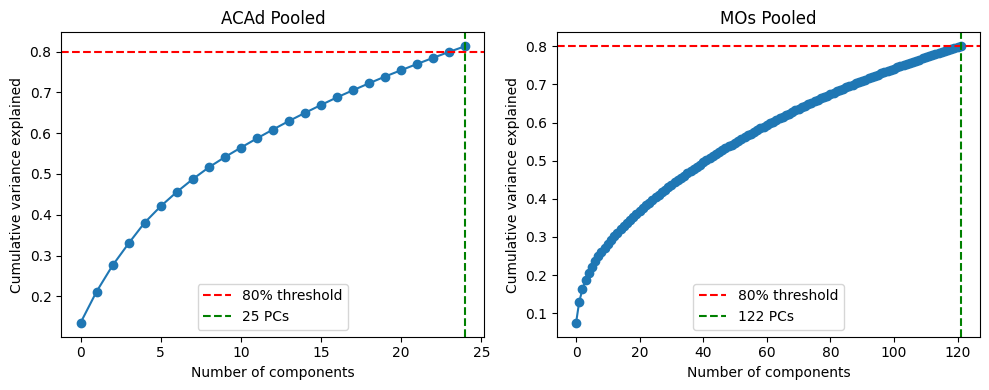

In [129]:
# Visualize variance explained (pooled PCA basis per area)
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].plot(A_cumvar[:A_npc], 'o-')
axes[0].axhline(0.8, color='r', linestyle='--', label='80% threshold')
axes[0].axvline(A_npc - 1, color='g', linestyle='--', label=f'{A_npc} PCs')
axes[0].set_title(f'{struct1} Pooled')
axes[0].set_xlabel('Number of components')
axes[0].set_ylabel('Cumulative variance explained')
axes[0].legend()

axes[1].plot(B_cumvar[:B_npc], 'o-')
axes[1].axhline(0.8, color='r', linestyle='--', label='80% threshold')
axes[1].axvline(B_npc - 1, color='g', linestyle='--', label=f'{B_npc} PCs')
axes[1].set_title(f'{struct2} Pooled')
axes[1].set_xlabel('Number of components')
axes[1].set_ylabel('Cumulative variance explained')
axes[1].legend()

plt.tight_layout()
plt.show()

## 5. Perform CCA Between Brain Areas

In [26]:
def run_cca(X1, X2, n_components=None):
    """Run CCA between two datasets."""
    d = min(X1.shape[1], X2.shape[1])
    if n_components is None:
        n_components = d
    n_components = min(n_components, d, X1.shape[0] - 1, X2.shape[0] - 1)
    if n_components < 1:
        raise ValueError("Not enough samples to fit CCA.")
    cca = CCA(n_components=n_components)
    cca.fit(X1, X2)
    X1_c, X2_c = cca.transform(X1, X2)
    return cca, X1_c, X2_c

print("CCA function defined")

CCA function defined


In [131]:
# Match dimensions between areas
A_task_pca_m, B_task_pca_m, d_task = match_dims(A_task_pca, B_task_pca)
A_spont_pca_m, B_spont_pca_m, d_spont = match_dims(A_spont_pca, B_spont_pca)

print(f"Matched dimensions - Task: {d_task}, Spontaneous: {d_spont}")

# Choose number of CCA components (e.g., 5 or all available)
k_task = min(10, d_task)
k_spont = min(10, d_spont)

print(f"CCA components - Task: {k_task}, Spontaneous: {k_spont}")

Matched dimensions - Task: 25, Spontaneous: 25
CCA components - Task: 10, Spontaneous: 10


In [132]:
# Run CCA for task and spontaneous epochs
cca_task, A_task_c, B_task_c = run_cca(A_task_pca_m, B_task_pca_m, n_components=k_task)
cca_spont, A_spont_c, B_spont_c = run_cca(A_spont_pca_m, B_spont_pca_m, n_components=k_spont)

print(f"CCA completed")
print(f"  Task canonical variables shape: {A_task_c.shape}")
print(f"  Spontaneous canonical variables shape: {A_spont_c.shape}")

CCA completed
  Task canonical variables shape: (538, 10)
  Spontaneous canonical variables shape: (91, 10)


## 6. Calculate Canonical Correlations

In [133]:
# Calculate canonical correlations
corrs_task = canonical_corrs(A_task_c, B_task_c)
corrs_spont = canonical_corrs(A_spont_c, B_spont_c)

print(f"\nCanonical correlations:")
print(f"  Task: {corrs_task}")
print(f"  Spontaneous: {corrs_spont}")

# Basic comparison
print(f"\nMean correlation:")
print(f"  Task: {np.mean(corrs_task):.3f}")
print(f"  Spontaneous: {np.mean(corrs_spont):.3f}")
print(f"  Difference: {np.mean(corrs_task) - np.mean(corrs_spont):.3f}")


Canonical correlations:
  Task: [0.9202608  0.88580211 0.83343797 0.76512413 0.6882951  0.61073526
 0.58790475 0.49494746 0.47193665 0.41753425]
  Spontaneous: [0.95656277 0.93488786 0.9045471  0.88047504 0.82397331 0.79120925
 0.78336926 0.77112993 0.75396967 0.71120753]

Mean correlation:
  Task: 0.668
  Spontaneous: 0.831
  Difference: -0.164


In [134]:
# transform task data into spontaneous CCA space
A_task_c_in_spont, B_task_c_in_spont = cca_spont.transform(A_task_pca_m,B_task_pca_m)
corrs_task_in_spont = canonical_corrs(A_task_c_in_spont, B_task_c_in_spont)

print(f"\nCanonical correlations for task data projected into spontaneous CCA space:")
print(f"  Task in Spont CCA space: {corrs_task_in_spont}")


#transform spontaneous data into task CCA space
A_spont_c_in_task, B_spont_c_in_task = cca_task.transform(A_spont_pca_m, B_spont_pca_m)
corrs_spont_in_task = canonical_corrs(A_spont_c_in_task, B_spont_c_in_task)

print(f"\nCanonical correlations for spontaneous data projected into task CCA space:")
print(f"  Spont in Task CCA space: {corrs_spont_in_task}")

# mean correlations:
print(f"\nMean correlations in cross-projected spaces:")
print(f"  Task in Spont CCA space: {np.mean(corrs_task_in_spont):.3f}")
print(f"  Spont in Task CCA space: {np.mean(corrs_spont_in_task):.3f}")


Canonical correlations for task data projected into spontaneous CCA space:
  Task in Spont CCA space: [ 0.31584482 -0.07772128  0.46090184  0.25755053  0.25449561  0.07389737
  0.40476696  0.16801413  0.06256671  0.02938926]

Canonical correlations for spontaneous data projected into task CCA space:
  Spont in Task CCA space: [ 0.65024581  0.69579673  0.40441326  0.30363521  0.44654921  0.23238325
  0.33399092 -0.12992257  0.02734828  0.30350182]

Mean correlations in cross-projected spaces:
  Task in Spont CCA space: 0.195
  Spont in Task CCA space: 0.327


## 7. Bootstrap Significance Testing

In [30]:
def bootstrap_corrs(X, Y, n_components, n_boot=1000):
    """Bootstrap canonical correlations within an epoch."""
    n_samples = X.shape[0]
    boot_corrs = np.zeros((n_boot, n_components))
    for b in range(n_boot):
        idx = np.random.choice(n_samples, n_samples, replace=True)
        cca, X_c, Y_c = run_cca(X[idx], Y[idx], n_components=n_components)
        boot_corrs[b] = canonical_corrs(X_c, Y_c)
    return boot_corrs

print("Bootstrap function defined")

Bootstrap function defined


In [118]:
# Run bootstrap for task and spontaneous (reduced iterations for speed)
n_boot = 500
print(f"Running bootstrap with {n_boot} iterations...")

boot_task = bootstrap_corrs(A_task_pca_m, B_task_pca_m, k_task, n_boot=n_boot)
boot_spont = bootstrap_corrs(A_spont_pca_m, B_spont_pca_m, k_spont, n_boot=n_boot)

# Calculate confidence intervals
task_ci = np.percentile(boot_task, [2.5, 97.5], axis=0)
spont_ci = np.percentile(boot_spont, [2.5, 97.5], axis=0)

print(f"\nBootstrap completed")
print(f"Task 95% CI for component 1: [{task_ci[0, 0]:.3f}, {task_ci[1, 0]:.3f}]")
print(f"Spontaneous 95% CI for component 1: [{spont_ci[0, 0]:.3f}, {spont_ci[1, 0]:.3f}]")

Running bootstrap with 500 iterations...


KeyboardInterrupt: 

In [29]:
# Test for significant difference between task and spontaneous
def bootstrap_diff(X1_task, Y1_task, X1_spont, Y1_spont, n_components, n_boot=1000):
    """Bootstrap the difference in canonical correlations between epochs."""
    n_task = X1_task.shape[0]
    n_spont = X1_spont.shape[0]
    diff_boot = np.zeros((n_boot, n_components))
    
    for b in range(n_boot):
        idx_task = np.random.choice(n_task, n_task, replace=True)
        idx_spont = np.random.choice(n_spont, n_spont, replace=True)
        
        _, X_task_c, Y_task_c = run_cca(X1_task[idx_task], Y1_task[idx_task], n_components)
        _, X_spont_c, Y_spont_c = run_cca(X1_spont[idx_spont], Y1_spont[idx_spont], n_components)
        
        r_task = canonical_corrs(X_task_c, Y_task_c)
        r_spont = canonical_corrs(X_spont_c, Y_spont_c)
        
        diff_boot[b] = r_task - r_spont
    
    return diff_boot

print("Bootstrap difference function defined")

Bootstrap difference function defined


In [72]:
# Run bootstrap for differences
k_min = min(k_task, k_spont)
print(f"Running bootstrap for differences with {n_boot} iterations...")

diff_boot = bootstrap_diff(
    A_task_pca_m, B_task_pca_m,
    A_spont_pca_m, B_spont_pca_m,
    n_components=k_min,
    n_boot=n_boot
)

diff_ci = np.percentile(diff_boot, [2.5, 97.5], axis=0)
diff_mean = np.mean(diff_boot, axis=0)

print(f"\nDifference in canonical correlations (Task - Spontaneous):")
for i in range(k_min):
    significant = "***" if (diff_ci[0, i] > 0 or diff_ci[1, i] < 0) else "n.s."
    print(f"  Component {i+1}: {diff_mean[i]:.3f} [{diff_ci[0, i]:.3f}, {diff_ci[1, i]:.3f}] {significant}")

Running bootstrap for differences with 500 iterations...


c:\Anaconda3\envs\dr_ibl_analysis\Lib\site-packages\sklearn\cross_decomposition\_pls.py:113: ConvergenceWarning: Maximum number of iterations reached
  warnings.warn("Maximum number of iterations reached", ConvergenceWarning)
c:\Anaconda3\envs\dr_ibl_analysis\Lib\site-packages\sklearn\cross_decomposition\_pls.py:113: ConvergenceWarning: Maximum number of iterations reached
  warnings.warn("Maximum number of iterations reached", ConvergenceWarning)
c:\Anaconda3\envs\dr_ibl_analysis\Lib\site-packages\sklearn\cross_decomposition\_pls.py:113: ConvergenceWarning: Maximum number of iterations reached
  warnings.warn("Maximum number of iterations reached", ConvergenceWarning)
c:\Anaconda3\envs\dr_ibl_analysis\Lib\site-packages\sklearn\cross_decomposition\_pls.py:113: ConvergenceWarning: Maximum number of iterations reached
  warnings.warn("Maximum number of iterations reached", ConvergenceWarning)
c:\Anaconda3\envs\dr_ibl_analysis\Lib\site-packages\sklearn\cross_decomposition\_pls.py:113: Con


Difference in canonical correlations (Task - Spontaneous):
  Component 1: -0.089 [-0.123, -0.052] ***
  Component 2: -0.156 [-0.195, -0.113] ***
  Component 3: -0.164 [-0.204, -0.126] ***
  Component 4: -0.168 [-0.208, -0.132] ***
  Component 5: -0.170 [-0.213, -0.133] ***
  Component 6: -0.172 [-0.214, -0.132] ***
  Component 7: -0.173 [-0.214, -0.133] ***
  Component 8: -0.176 [-0.215, -0.135] ***
  Component 9: -0.176 [-0.212, -0.138] ***
  Component 10: -0.176 [-0.219, -0.137] ***


## 8. Compare Communication Subspaces Across Epochs

In [28]:
def principal_angles(U, V):
    """
    Calculate principal angles between two subspaces.
    U, V: (d × k) matrices.
    Returns principal angles in radians.
    """
    Uo, _ = np.linalg.qr(U)
    Vo, _ = np.linalg.qr(V)
    s = np.linalg.svd(Uo.T @ Vo, compute_uv=False)
    s = np.clip(s, -1.0, 1.0)
    return np.arccos(s)

print("Principal angles function defined")

Principal angles function defined


In [136]:
# Compare subspaces for area A (struct1)
k = min(k_task, k_spont)
subspace_compare_mode = "pooled_pca"  # "pooled_pca" or "neuron_space"

if subspace_compare_mode == "pooled_pca":
    U_task_A = cca_task.x_weights_[:, :k]
    U_spont_A = cca_spont.x_weights_[:, :k]
    U_task_B = cca_task.y_weights_[:, :k]
    U_spont_B = cca_spont.y_weights_[:, :k]
elif subspace_compare_mode == "neuron_space":
    U_task_A = pca_A.components_.T @ cca_task.x_weights_[:, :k]
    U_spont_A = pca_A.components_.T @ cca_spont.x_weights_[:, :k]
    U_task_B = pca_B.components_.T @ cca_task.y_weights_[:, :k]
    U_spont_B = pca_B.components_.T @ cca_spont.y_weights_[:, :k]
else:
    raise ValueError("subspace_compare_mode must be 'pooled_pca' or 'neuron_space'.")

angles_A = principal_angles(U_task_A, U_spont_A)
angles_A_deg = angles_A * 180 / np.pi

print(f"\nPrincipal angles for {struct1} (degrees):")
print(angles_A_deg)
print(f"Mean angle: {np.mean(angles_A_deg):.2f}°")

angles_B = principal_angles(U_task_B, U_spont_B)
angles_B_deg = angles_B * 180 / np.pi

print(f"\nPrincipal angles for {struct2} (degrees):")
print(angles_B_deg)
print(f"Mean angle: {np.mean(angles_B_deg):.2f}°")


Principal angles for ACAd (degrees):
[10.12929247 20.36005235 35.17828498 38.31183553 40.17291185 52.52144107
 59.6453343  68.55680886 75.12948075 87.28612716]
Mean angle: 48.73°

Principal angles for MOs (degrees):
[ 8.81213357 18.95045218 22.85287794 31.65049831 41.16112914 43.63804597
 62.88855895 68.90272287 80.8168978  86.52219464]
Mean angle: 46.62°


## 9. Visualize Canonical Correlations

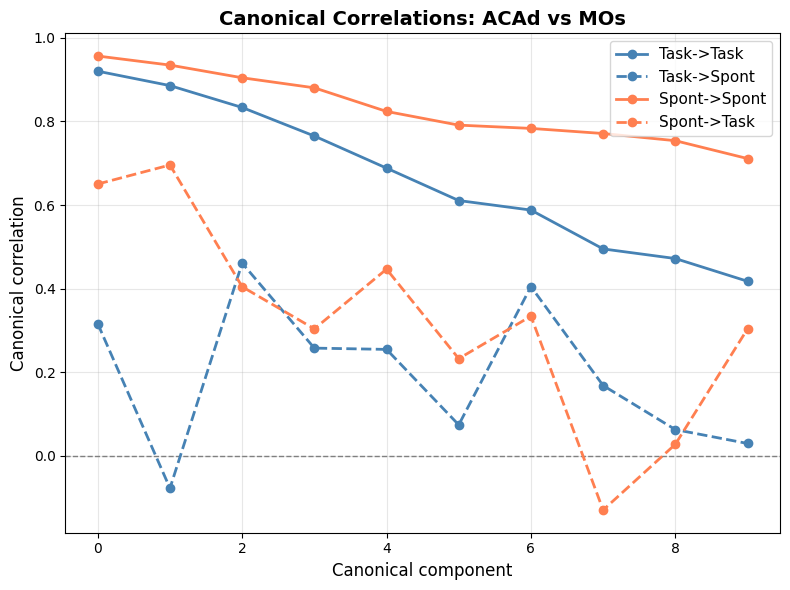

In [137]:
# Plot canonical correlations with bootstrap confidence intervals
fig, ax = plt.subplots(1, 1, figsize=(8, 6))

x_task = np.arange(len(corrs_task))
x_spont = np.arange(len(corrs_spont))

ax.axhline(0, color='gray', linestyle='--', linewidth=1)

# Plot task
ax.errorbar(
    x_task, corrs_task,
    # yerr=np.abs([task_ci[0]-corrs_task, task_ci[1]-corrs_task]),
    fmt='o-', linewidth=2, capsize=5, capthick=2,
    label='Task->Task', color='steelblue'
)

ax.errorbar(
    x_task, corrs_task_in_spont,
    # yerr=np.abs([task_ci[0]-corrs_task_in_spont, task_ci[1]-corrs_task_in_spont]),
    fmt='o--', linewidth=2, capsize=5, capthick=2,
    label='Task->Spont', color='steelblue'
)

# Plot spontaneous
ax.errorbar(
    x_spont, corrs_spont,
    # yerr=[spont_ci[0]-corrs_spont, spont_ci[1]-corrs_spont],
    fmt='o-', linewidth=2, capsize=5, capthick=2,
    label='Spont->Spont', color='coral'
)

ax.errorbar(
    x_spont, corrs_spont_in_task,
    # yerr=[spont_ci[0]-corrs_spont_in_task, spont_ci[1]-corrs_spont_in_task],
    fmt='o--', linewidth=2, capsize=5, capthick=2,
    label='Spont->Task', color='coral'
)

ax.set_xlabel('Canonical component', fontsize=12)
ax.set_ylabel('Canonical correlation', fontsize=12)
ax.set_title(f'Canonical Correlations: {struct1} vs {struct2}', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(alpha=0.3)
# ax.set_ylim([0, 1])

plt.tight_layout()
plt.show()

In [138]:
# [task_ci[0]-corrs_task, task_ci[1]-corrs_task]

NameError: name 'boot_task' is not defined

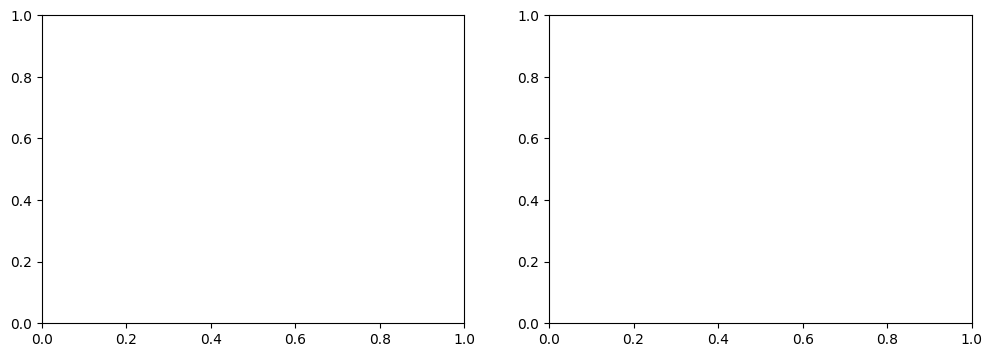

In [139]:
# Plot bootstrap distributions for first canonical component
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(boot_task[:, 0], bins=30, alpha=0.7, color='steelblue', label='Task')
axes[0].hist(boot_spont[:, 0], bins=30, alpha=0.7, color='coral', label='Spontaneous')
axes[0].axvline(corrs_task[0], color='steelblue', linestyle='--', linewidth=2, label='Task observed')
axes[0].axvline(corrs_spont[0], color='coral', linestyle='--', linewidth=2, label='Spont observed')
axes[0].set_xlabel('Canonical correlation', fontsize=11)
axes[0].set_ylabel('Bootstrap count', fontsize=11)
axes[0].set_title('Bootstrap Distribution: Component 1', fontsize=12, fontweight='bold')
axes[0].legend(fontsize=10)

# Plot difference distribution
axes[1].hist(diff_boot[:, 0], bins=30, alpha=0.7, color='purple')
axes[1].axvline(0, color='black', linestyle='--', linewidth=2, label='No difference')
axes[1].axvline(diff_mean[0], color='red', linestyle='--', linewidth=2, label='Observed difference')
axes[1].axvline(diff_ci[0, 0], color='red', linestyle=':', linewidth=1.5, label='95% CI')
axes[1].axvline(diff_ci[1, 0], color='red', linestyle=':', linewidth=1.5)
axes[1].set_xlabel('Difference (Task - Spontaneous)', fontsize=11)
axes[1].set_ylabel('Bootstrap count', fontsize=11)
axes[1].set_title('Bootstrap Difference: Component 1', fontsize=12, fontweight='bold')
axes[1].legend(fontsize=10)

plt.tight_layout()
plt.show()

## 10. Visualize Subspace Angles

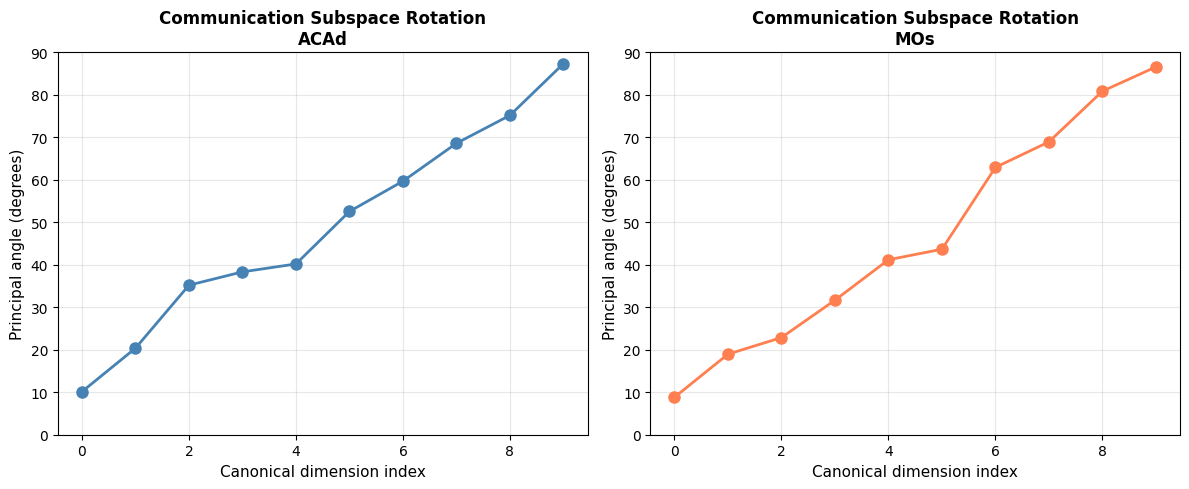


Interpretation:
  Small angles (< 30°): Subspaces are very similar between task and spontaneous
  Medium angles (30-60°): Moderate rotation of subspaces
  Large angles (> 60°): Substantial reorganization of communication subspace


In [140]:
# Plot principal angles
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].plot(angles_A_deg, 'o-', linewidth=2, markersize=8, color='steelblue')
axes[0].set_xlabel('Canonical dimension index', fontsize=11)
axes[0].set_ylabel('Principal angle (degrees)', fontsize=11)
axes[0].set_title(f'Communication Subspace Rotation\n{struct1}', fontsize=12, fontweight='bold')
axes[0].grid(alpha=0.3)
axes[0].set_ylim([0, 90])

axes[1].plot(angles_B_deg, 'o-', linewidth=2, markersize=8, color='coral')
axes[1].set_xlabel('Canonical dimension index', fontsize=11)
axes[1].set_ylabel('Principal angle (degrees)', fontsize=11)
axes[1].set_title(f'Communication Subspace Rotation\n{struct2}', fontsize=12, fontweight='bold')
axes[1].grid(alpha=0.3)
axes[1].set_ylim([0, 90])

plt.tight_layout()
plt.show()

print(f"\nInterpretation:")
print(f"  Small angles (< 30°): Subspaces are very similar between task and spontaneous")
print(f"  Medium angles (30-60°): Moderate rotation of subspaces")
print(f"  Large angles (> 60°): Substantial reorganization of communication subspace")

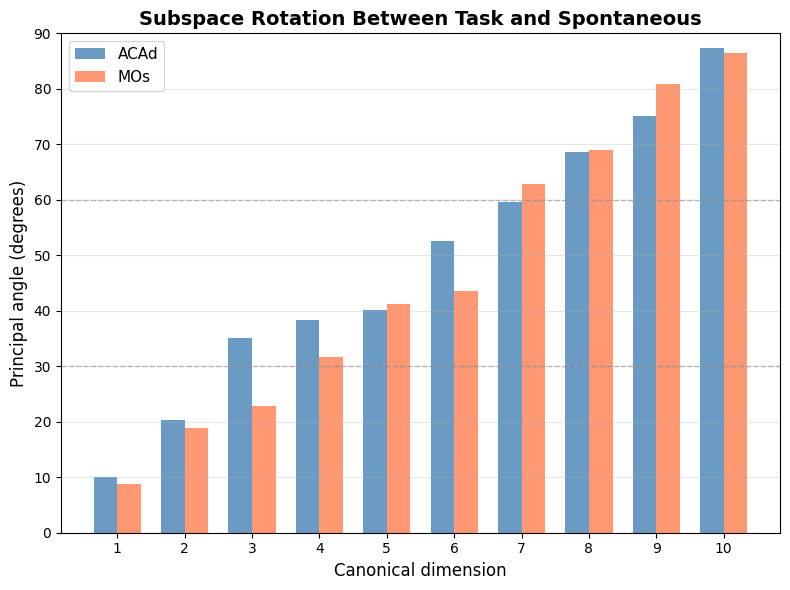

In [141]:
# Combined visualization of angles
fig, ax = plt.subplots(1, 1, figsize=(8, 6))

x = np.arange(len(angles_A_deg))
width = 0.35

bars1 = ax.bar(x - width/2, angles_A_deg, width, label=struct1, color='steelblue', alpha=0.8)
bars2 = ax.bar(x + width/2, angles_B_deg, width, label=struct2, color='coral', alpha=0.8)

ax.set_xlabel('Canonical dimension', fontsize=12)
ax.set_ylabel('Principal angle (degrees)', fontsize=12)
ax.set_title('Subspace Rotation Between Task and Spontaneous', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels([f'{i+1}' for i in x])
ax.legend(fontsize=11)
ax.grid(axis='y', alpha=0.3)
ax.set_ylim([0, 90])

# Add reference lines
ax.axhline(30, color='gray', linestyle='--', linewidth=1, alpha=0.5)
ax.axhline(60, color='gray', linestyle='--', linewidth=1, alpha=0.5)

plt.tight_layout()
plt.show()

## 11. Plot Canonical Variable Trajectories

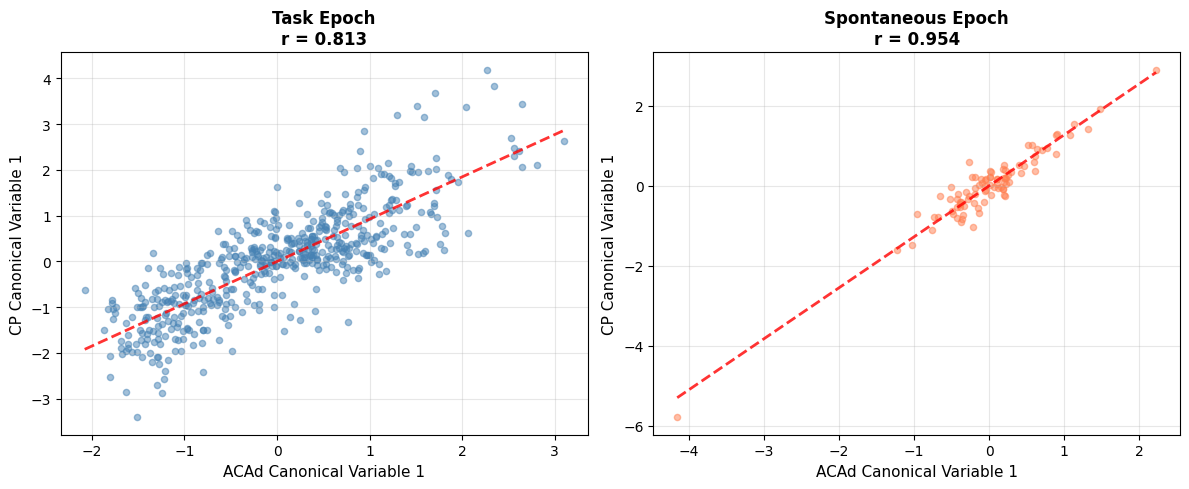

In [104]:
# Plot relationship between canonical variables for first component
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Task
axes[0].scatter(A_task_c[:, 0], B_task_c[:, 0], alpha=0.5, s=20, color='steelblue')
axes[0].set_xlabel(f'{struct1} Canonical Variable 1', fontsize=11)
axes[0].set_ylabel(f'{struct2} Canonical Variable 1', fontsize=11)
axes[0].set_title(f'Task Epoch\nr = {corrs_task[0]:.3f}', fontsize=12, fontweight='bold')
axes[0].grid(alpha=0.3)

# Add regression line
z = np.polyfit(A_task_c[:, 0], B_task_c[:, 0], 1)
p = np.poly1d(z)
x_line = np.linspace(A_task_c[:, 0].min(), A_task_c[:, 0].max(), 100)
axes[0].plot(x_line, p(x_line), "r--", linewidth=2, alpha=0.8)

# Spontaneous
axes[1].scatter(A_spont_c[:, 0], B_spont_c[:, 0], alpha=0.5, s=20, color='coral')
axes[1].set_xlabel(f'{struct1} Canonical Variable 1', fontsize=11)
axes[1].set_ylabel(f'{struct2} Canonical Variable 1', fontsize=11)
axes[1].set_title(f'Spontaneous Epoch\nr = {corrs_spont[0]:.3f}', fontsize=12, fontweight='bold')
axes[1].grid(alpha=0.3)

# Add regression line
z = np.polyfit(A_spont_c[:, 0], B_spont_c[:, 0], 1)
p = np.poly1d(z)
x_line = np.linspace(A_spont_c[:, 0].min(), A_spont_c[:, 0].max(), 100)
axes[1].plot(x_line, p(x_line), "r--", linewidth=2, alpha=0.8)

plt.tight_layout()
plt.show()

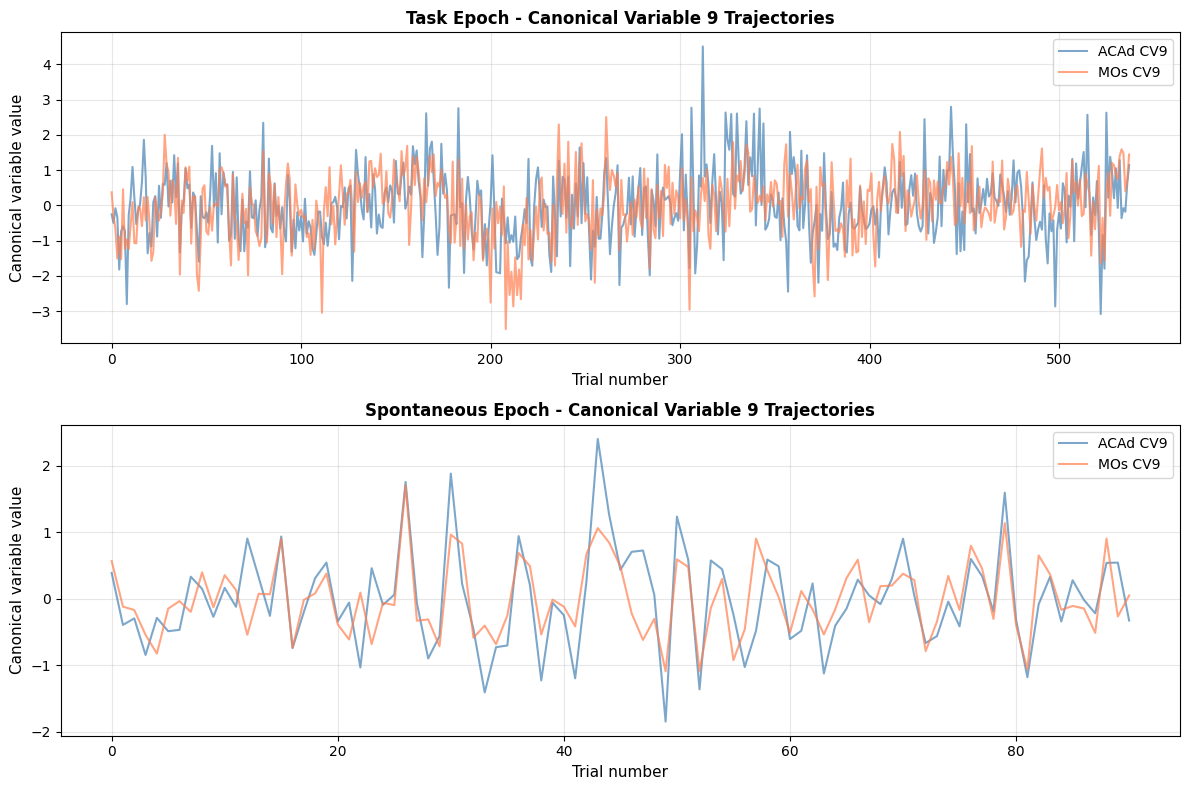

In [142]:
# Plot time series of canonical variables (first component)
plot_component=9

fig, axes = plt.subplots(2, 1, figsize=(12, 8))

# Task
axes[0].plot(A_task_c[:, plot_component], label=f'{struct1} CV{plot_component}', linewidth=1.5, alpha=0.7, color='steelblue')
axes[0].plot(B_task_c[:, plot_component], label=f'{struct2} CV{plot_component}', linewidth=1.5, alpha=0.7, color='coral')
axes[0].set_xlabel('Trial number', fontsize=11)
axes[0].set_ylabel('Canonical variable value', fontsize=11)
axes[0].set_title(f'Task Epoch - Canonical Variable {plot_component} Trajectories', fontsize=12, fontweight='bold')
axes[0].legend(fontsize=10)
axes[0].grid(alpha=0.3)

# Spontaneous
axes[1].plot(A_spont_c[:, plot_component], label=f'{struct1} CV{plot_component}', linewidth=1.5, alpha=0.7, color='steelblue')
axes[1].plot(B_spont_c[:, plot_component], label=f'{struct2} CV{plot_component}', linewidth=1.5, alpha=0.7, color='coral')
axes[1].set_xlabel('Trial number', fontsize=11)
axes[1].set_ylabel('Canonical variable value', fontsize=11)
axes[1].set_title(f'Spontaneous Epoch - Canonical Variable {plot_component} Trajectories', fontsize=12, fontweight='bold')
axes[1].legend(fontsize=10)
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

## Summary

This analysis applies CCA to assess neural coupling between brain areas across task and spontaneous epochs:

1. **PCA preprocessing**: Reduced dimensionality while retaining 80% variance for each area/epoch
2. **CCA**: Identified maximally correlated dimensions between paired brain areas
3. **Bootstrap testing**: Quantified statistical significance of correlations and differences
4. **Subspace comparison**: Measured rotation of communication subspaces via principal angles
5. **Visualization**: Comprehensive plots showing correlation strength, confidence intervals, and trajectories

**Key findings:**
- Canonical correlations quantify trial-by-trial coupling between areas
- Bootstrap CI indicates reliability of estimated correlations
- Principal angles reveal whether the neural subspace mediating communication changes between epochs
- Small angles suggest persistent communication structure; large angles indicate reorganization

In [1]:
# Optional: Save results for further analysis
results = {
    'structures': [struct1, struct2],
    'canonical_correlations': {
        'task': corrs_task,
        'spontaneous': corrs_spont,
        'difference': corrs_task[:k_min] - corrs_spont[:k_min]
    },
    'bootstrap': {
        'task_ci': task_ci,
        'spont_ci': spont_ci,
        'diff_ci': diff_ci,
        'diff_mean': diff_mean
    },
    'principal_angles': {
        struct1: angles_A_deg,
        struct2: angles_B_deg
    },
    'n_components': {
        'task': k_task,
        'spontaneous': k_spont
    }
}

print("\nAnalysis complete! Results dictionary contains:")
for key in results.keys():
    print(f"  - {key}")

NameError: name 'struct1' is not defined

## 12. All-Pairs CCA Analysis

Run the full CCA pipeline for every pair of brain areas recorded in this session.  
PCA bases are fit **once per structure** (pooled across task + spontaneous), then reused across all pairs for efficiency.

Results are collected into a tidy `pandas.DataFrame` with one row per (struct1, struct2, canonical component).


In [18]:
from itertools import combinations

# ── Configuration ──────────────────────────────────────────────────────────────
MIN_UNITS      = 5      # minimum units required in a structure to include it
VAR_THRESH     = 0.80   # PCA variance threshold
MAX_CCA_COMPS  = 10     # cap on number of CCA components per pair
N_BOOT         = 0 #200    # bootstrap iterations (set to 0 to skip bootstrapping)

# ── Identify qualifying structures ─────────────────────────────────────────────
unit_counts = units_filtered.groupby('structure')['unit_id'].nunique()
qualified_structures = sorted(unit_counts[unit_counts >= MIN_UNITS].index.tolist())

print(f"Structures with >= {MIN_UNITS} units: {len(qualified_structures)}")
print(qualified_structures)
n_pairs = len(qualified_structures) * (len(qualified_structures) - 1) // 2
print(f"Total pairs to analyse: {n_pairs}")


Structures with >= 5 units: 19
['ACAd', 'ACAv', 'CA1', 'CA3', 'CP', 'FRP', 'GU', 'ILA', 'LSr', 'MOs', 'OLF', 'ORBl', 'ORBm', 'ORBvl', 'PL', 'SSp', 'SSs', 'TTd', 'VISal']
Total pairs to analyse: 171


In [19]:
# ── Pre-compute data arrays and pooled PCA for each qualifying structure ────────
# Re-use the already-loaded trial_da / spont_trial_da tensors.

struct_data = {}   # struct -> {'task_z': ..., 'spont_z': ..., 'pca': ..., 'n_pc': ...}
time_idx = 0       # single time-bin (matches earlier analysis)

for struct in qualified_structures:
    uid = units_filtered[units_filtered['structure'] == struct]['unit_id'].unique()

    # raw (trials × neurons) matrices
    A_task  = trial_da.sel(unit_id=uid).data[:, time_idx, :].T
    A_spont = spont_trial_da.sel(unit_id=uid).data[:, time_idx, :].T

    # pooled z-score (same scaler for both epochs)
    A_pool_raw = np.vstack([A_task, A_spont])
    scaler_pool = StandardScaler().fit(A_pool_raw)
    A_pool_z = scaler_pool.transform(A_pool_raw)

    A_task_z  = A_pool_z[:A_task.shape[0]]
    A_spont_z = A_pool_z[A_task.shape[0]:]

    # fit PCA on pooled z-scored data
    pca, n_pc, cumvar = pca_fit_keep(A_pool_z, var_thresh=VAR_THRESH)

    struct_data[struct] = {
        'task_z'   : A_task_z,
        'spont_z'  : A_spont_z,
        'pca'      : pca,
        'n_pc'     : n_pc,
        'n_units'  : len(uid),
        'task_pca' : pca.transform(A_task_z),
        'spont_pca': pca.transform(A_spont_z),
    }

print("Per-structure PCA complete.")
for s, d in struct_data.items():
    print(f"  {s:15s}  units={d['n_units']:3d}  PCs={d['n_pc']:3d}")


Per-structure PCA complete.
  ACAd             units= 48  PCs= 25
  ACAv             units= 24  PCs= 15
  CA1              units= 10  PCs=  6
  CA3              units=  5  PCs=  4
  CP               units= 61  PCs= 33
  FRP              units= 13  PCs=  8
  GU               units= 27  PCs= 19
  ILA              units=131  PCs= 68
  LSr              units= 28  PCs= 17
  MOs              units=302  PCs=122
  OLF              units=  6  PCs=  5
  ORBl             units= 62  PCs= 32
  ORBm             units= 64  PCs= 34
  ORBvl            units=179  PCs= 84
  PL               units= 46  PCs= 26
  SSp              units=249  PCs=110
  SSs              units= 97  PCs= 53
  TTd              units= 66  PCs= 41
  VISal            units= 18  PCs= 10


In [24]:
def run_cca_pair(dA, dB, max_cca_comps=MAX_CCA_COMPS, n_boot=N_BOOT):
    """
    Run the full CCA pipeline for a single (struct_A, struct_B) pair.

    Parameters
    ----------
    dA, dB : dict
        Per-structure data dicts produced by the pre-computation cell above.
        Required keys: 'task_pca', 'spont_pca', 'n_pc', 'n_units'.
    max_cca_comps : int
        Maximum number of CCA components to retain.
    n_boot : int
        Bootstrap iterations. 0 skips bootstrapping.

    Returns
    -------
    list[dict]
        One record per canonical component containing all summary metrics.
    """
    # Match PCA dimensions between the two areas
    A_task_m,  B_task_m,  d_task  = match_dims(dA['task_pca'],  dB['task_pca'])
    A_spont_m, B_spont_m, d_spont = match_dims(dA['spont_pca'], dB['spont_pca'])

    k_task  = min(max_cca_comps, d_task,  A_task_m.shape[0]  - 1, B_task_m.shape[0]  - 1)
    k_spont = min(max_cca_comps, d_spont, A_spont_m.shape[0] - 1, B_spont_m.shape[0] - 1)
    k       = min(k_task, k_spont)

    if k < 1:
        return []

    # Fit CCA for each epoch
    try:
        cca_task,  A_task_c,  B_task_c  = run_cca(A_task_m,  B_task_m,  n_components=k)
        cca_spont, A_spont_c, B_spont_c = run_cca(A_spont_m, B_spont_m, n_components=k)
    except Exception:
        print(f"CCA failed for pair with {dA['n_units']} and {dB['n_units']} units (k={k}). Skipping.")
        return []

    # Canonical correlations (in-epoch)
    r_task  = canonical_corrs(A_task_c,  B_task_c)
    r_spont = canonical_corrs(A_spont_c, B_spont_c)

    # Cross-projected correlations
    A_task_in_spont, B_task_in_spont   = cca_spont.transform(A_task_m[:, :d_spont],  B_task_m[:, :d_spont])
    A_spont_in_task, B_spont_in_task   = cca_task.transform( A_spont_m[:, :d_task],  B_spont_m[:, :d_task])
    r_task_in_spont  = canonical_corrs(A_task_in_spont,  B_task_in_spont)
    r_spont_in_task  = canonical_corrs(A_spont_in_task, B_spont_in_task)

    # Principal angles between CCA weight subspaces
    U_task_A  = cca_task.x_weights_[:, :k]
    U_spont_A = cca_spont.x_weights_[:, :k]
    U_task_B  = cca_task.y_weights_[:, :k]
    U_spont_B = cca_spont.y_weights_[:, :k]

    angles_A_deg = principal_angles(U_task_A, U_spont_A) * 180 / np.pi
    angles_B_deg = principal_angles(U_task_B, U_spont_B) * 180 / np.pi

    # Bootstrap CIs on in-epoch correlations (optional)
    task_ci  = np.full((2, k), np.nan)
    spont_ci = np.full((2, k), np.nan)
    if n_boot > 0:
        boot_task  = bootstrap_corrs(A_task_m,  B_task_m,  n_components=k, n_boot=n_boot)
        boot_spont = bootstrap_corrs(A_spont_m, B_spont_m, n_components=k, n_boot=n_boot)
        task_ci  = np.percentile(boot_task,  [2.5, 97.5], axis=0)
        spont_ci = np.percentile(boot_spont, [2.5, 97.5], axis=0)

    # Pack into one record per CCA component
    records = []
    for i in range(k):
        records.append({
            'component'          : i + 1,
            'n_cca_comps'        : k,
            'r_task'             : r_task[i],
            'r_spont'            : r_spont[i],
            'r_task_in_spont'    : r_task_in_spont[i],
            'r_spont_in_task'    : r_spont_in_task[i],
            'r_task_ci_lo'       : task_ci[0, i],
            'r_task_ci_hi'       : task_ci[1, i],
            'r_spont_ci_lo'      : spont_ci[0, i],
            'r_spont_ci_hi'      : spont_ci[1, i],
            'angle_A_deg'        : angles_A_deg[i],
            'angle_B_deg'        : angles_B_deg[i],
            'n_pca_A'            : dA['n_pc'],
            'n_pca_B'            : dB['n_pc'],
            'n_units_A'          : dA['n_units'],
            'n_units_B'          : dB['n_units'],
            'n_task_trials'      : A_task_m.shape[0],
            'n_spont_trials'     : A_spont_m.shape[0],
        })
    return records

print("run_cca_pair() defined.")


run_cca_pair() defined.


In [31]:
import time

all_records = []
pairs = list(combinations(qualified_structures, 2))

print(f"Running CCA for {len(pairs)} pairs  (n_boot={N_BOOT})...")
t0 = time.time()

for idx, (sA, sB) in enumerate(pairs):
    pair_records = run_cca_pair(struct_data[sA], struct_data[sB])
    for rec in pair_records:
        rec['struct_A'] = sA
        rec['struct_B'] = sB
    all_records.extend(pair_records)

    if (idx + 1) % 10 == 0 or (idx + 1) == len(pairs):
        elapsed = time.time() - t0
        print(f"  {idx+1:3d}/{len(pairs)}  ({elapsed:.0f}s)")

print(f"\nDone.  {len(all_records)} component-level records collected.")


Running CCA for 171 pairs  (n_boot=0)...
   10/171  (1s)
   20/171  (3s)
   30/171  (3s)
   40/171  (3s)
   50/171  (3s)
   60/171  (4s)
   70/171  (8s)
   80/171  (23s)
   90/171  (23s)
  100/171  (24s)


c:\Anaconda3\envs\dr_ibl_analysis\Lib\site-packages\sklearn\cross_decomposition\_pls.py:113: ConvergenceWarning: Maximum number of iterations reached
  warnings.warn("Maximum number of iterations reached", ConvergenceWarning)


  110/171  (26s)
  120/171  (31s)
  130/171  (33s)
  140/171  (36s)
  150/171  (39s)


c:\Anaconda3\envs\dr_ibl_analysis\Lib\site-packages\sklearn\cross_decomposition\_pls.py:113: ConvergenceWarning: Maximum number of iterations reached
  warnings.warn("Maximum number of iterations reached", ConvergenceWarning)


  160/171  (42s)
  170/171  (50s)
  171/171  (50s)

Done.  1423 component-level records collected.


In [32]:
# struct_data[sA]

In [34]:
# ── Build tidy results DataFrame ───────────────────────────────────────────────
col_order = [
    'session_id',
    'struct_A', 'struct_B',
    'n_units_A', 'n_units_B',
    'n_pca_A', 'n_pca_B',
    'n_task_trials', 'n_spont_trials',
    'n_cca_comps', 'component',
    'r_task',             'r_task_ci_lo',    'r_task_ci_hi',
    'r_spont',            'r_spont_ci_lo',   'r_spont_ci_hi',
    'r_task_in_spont',
    'r_spont_in_task',
    'angle_A_deg', 'angle_B_deg',
]

cca_results_df = (
    pd.DataFrame(all_records)
    .assign(session_id=session_id)
    [col_order]
    .sort_values(['struct_A', 'struct_B', 'component'])
    .reset_index(drop=True)
)

print(f"Shape: {cca_results_df.shape}")
print("\nColumn descriptions:")
print("  r_task          – canonical correlation computed on task trials")
print("  r_spont         – canonical correlation computed on spontaneous trials")
print("  r_task_in_spont – task data projected into spontaneous CCA space")
print("  r_spont_in_task – spont data projected into task CCA space")
print("  angle_A_deg     – principal angle between struct_A CCA weights (task vs spont)")
print("  angle_B_deg     – principal angle between struct_B CCA weights (task vs spont)")
print()
cca_results_df.head(20)


Shape: (1423, 21)

Column descriptions:
  r_task          – canonical correlation computed on task trials
  r_spont         – canonical correlation computed on spontaneous trials
  r_task_in_spont – task data projected into spontaneous CCA space
  r_spont_in_task – spont data projected into task CCA space
  angle_A_deg     – principal angle between struct_A CCA weights (task vs spont)
  angle_B_deg     – principal angle between struct_B CCA weights (task vs spont)



,session_id,struct_A,struct_B,n_units_A,n_units_B,n_pca_A,n_pca_B,n_task_trials,n_spont_trials,n_cca_comps,...,r_task,r_task_ci_lo,r_task_ci_hi,r_spont,r_spont_ci_lo,r_spont_ci_hi,r_task_in_spont,r_spont_in_task,angle_A_deg,angle_B_deg
0,742903_2024-10-22,ACAd,ACAv,48,24,25,15,538,91,10,...,0.885966,NaN,NaN,0.939146,NaN,NaN,0.807407,0.859454,0.000000e+00,0.000000e+00
1,742903_2024-10-22,ACAd,ACAv,48,24,25,15,538,91,10,...,0.749413,NaN,NaN,0.838379,NaN,NaN,0.452323,0.440473,0.000000e+00,0.000000e+00
2,742903_2024-10-22,ACAd,ACAv,48,24,25,15,538,91,10,...,0.572049,NaN,NaN,0.692673,NaN,NaN,0.013534,0.554833,0.000000e+00,8.537736e-07
3,742903_2024-10-22,ACAd,ACAv,48,24,25,15,538,91,10,...,0.516642,NaN,NaN,0.630000,NaN,NaN,0.511556,-0.106577,8.537736e-07,1.478779e-06
4,742903_2024-10-22,ACAd,ACAv,48,24,25,15,538,91,10,...,0.431858,NaN,NaN,0.572630,NaN,NaN,-0.565675,-0.059704,1.207418e-06,1.707547e-06
5,742903_2024-10-22,ACAd,ACAv,48,24,25,15,538,91,10,...,0.340657,NaN,NaN,0.539676,NaN,NaN,0.185752,-0.063123,3.007735e+01,2.516755e+01
6,742903_2024-10-22,ACAd,ACAv,48,24,25,15,538,91,10,...,0.289623,NaN,NaN,0.467519,NaN,NaN,0.023947,0.172140,3.267140e+01,4.444284e+01
7,742903_2024-10-22,ACAd,ACAv,48,24,25,15,538,91,10,...,0.248510,NaN,NaN,0.423489,NaN,NaN,-0.014861,-0.013186,5.533803e+01,5.524898e+01
8,742903_2024-10-22,ACAd,ACAv,48,24,25,15,538,91,10,...,0.217288,NaN,NaN,0.370794,NaN,NaN,0.043510,-0.402884,6.572396e+01,7.130894e+01
9,742903_2024-10-22,ACAd,ACAv,48,24,25,15,538,91,10,...,0.172864,NaN,NaN,0.327079,NaN,NaN,0.017402,0.205554,8.474989e+01,8.870810e+01


In [35]:
# ── Pair-level summary table (mean across components) ──────────────────────────
summary_df = (
    cca_results_df
    .groupby(['session_id', 'struct_A', 'struct_B', 'n_units_A', 'n_units_B',
              'n_pca_A', 'n_pca_B', 'n_task_trials', 'n_spont_trials', 'n_cca_comps'],
             sort=False)
    .agg(
        mean_r_task          = ('r_task',          'mean'),
        mean_r_spont         = ('r_spont',         'mean'),
        mean_r_task_in_spont = ('r_task_in_spont', 'mean'),
        mean_r_spont_in_task = ('r_spont_in_task', 'mean'),
        mean_angle_A_deg     = ('angle_A_deg',     'mean'),
        mean_angle_B_deg     = ('angle_B_deg',     'mean'),
        # component 1 values for quick reference
        r_task_comp1         = ('r_task',   'first'),
        r_spont_comp1        = ('r_spont',  'first'),
    )
    .assign(
        delta_r_task_spont = lambda d: d['mean_r_task'] - d['mean_r_spont'],
    )
    .sort_values('mean_r_task', ascending=False)
    .reset_index()
)

print(f"Pair-level summary: {len(summary_df)} pairs")
summary_df.head(20)


Pair-level summary: 171 pairs


,session_id,struct_A,struct_B,n_units_A,n_units_B,n_pca_A,n_pca_B,n_task_trials,n_spont_trials,n_cca_comps,mean_r_task,mean_r_spont,mean_r_task_in_spont,mean_r_spont_in_task,mean_angle_A_deg,mean_angle_B_deg,r_task_comp1,r_spont_comp1,delta_r_task_spont
0,742903_2024-10-22,MOs,SSp,302,249,122,110,538,91,10,0.888622,1.000000,0.066056,0.274005,74.226266,63.911897,0.976661,1.000000,-0.111378
1,742903_2024-10-22,MOs,ORBvl,302,179,122,84,538,91,10,0.790476,0.945110,-0.034052,0.154619,70.273844,66.803259,0.924385,1.000000,-0.154634
2,742903_2024-10-22,ORBvl,SSp,179,249,84,110,538,91,10,0.767609,0.935550,0.018014,0.161549,67.961497,67.869452,0.904034,1.000000,-0.167941
3,742903_2024-10-22,ILA,MOs,131,302,68,122,538,91,10,0.766736,1.000000,0.054373,0.167868,63.805061,64.301457,0.908243,1.000000,-0.233264
4,742903_2024-10-22,ILA,ORBvl,131,179,68,84,538,91,10,0.743198,0.983491,0.027639,0.328249,62.573727,65.542731,0.892801,1.000000,-0.240292
5,742903_2024-10-22,SSp,SSs,249,97,110,53,538,91,10,0.735659,0.970801,0.048358,0.274565,61.394468,64.207263,0.907252,0.999997,-0.235143
6,742903_2024-10-22,MOs,ORBl,302,62,122,32,538,91,10,0.730923,0.898524,0.238057,0.387311,50.457726,51.630629,0.933004,0.968901,-0.167601
7,742903_2024-10-22,ILA,SSp,131,249,68,110,538,91,10,0.728295,1.000000,-0.009851,0.151849,65.560746,66.561465,0.893490,1.000000,-0.271705
8,742903_2024-10-22,MOs,SSs,302,97,122,53,538,91,10,0.700967,0.982372,0.031857,0.222108,64.729904,64.830059,0.903322,0.999989,-0.281405
9,742903_2024-10-22,ILA,ORBm,131,64,68,34,538,91,10,0.692048,0.910076,0.146140,0.280490,52.318796,54.241926,0.902826,0.973828,-0.218028


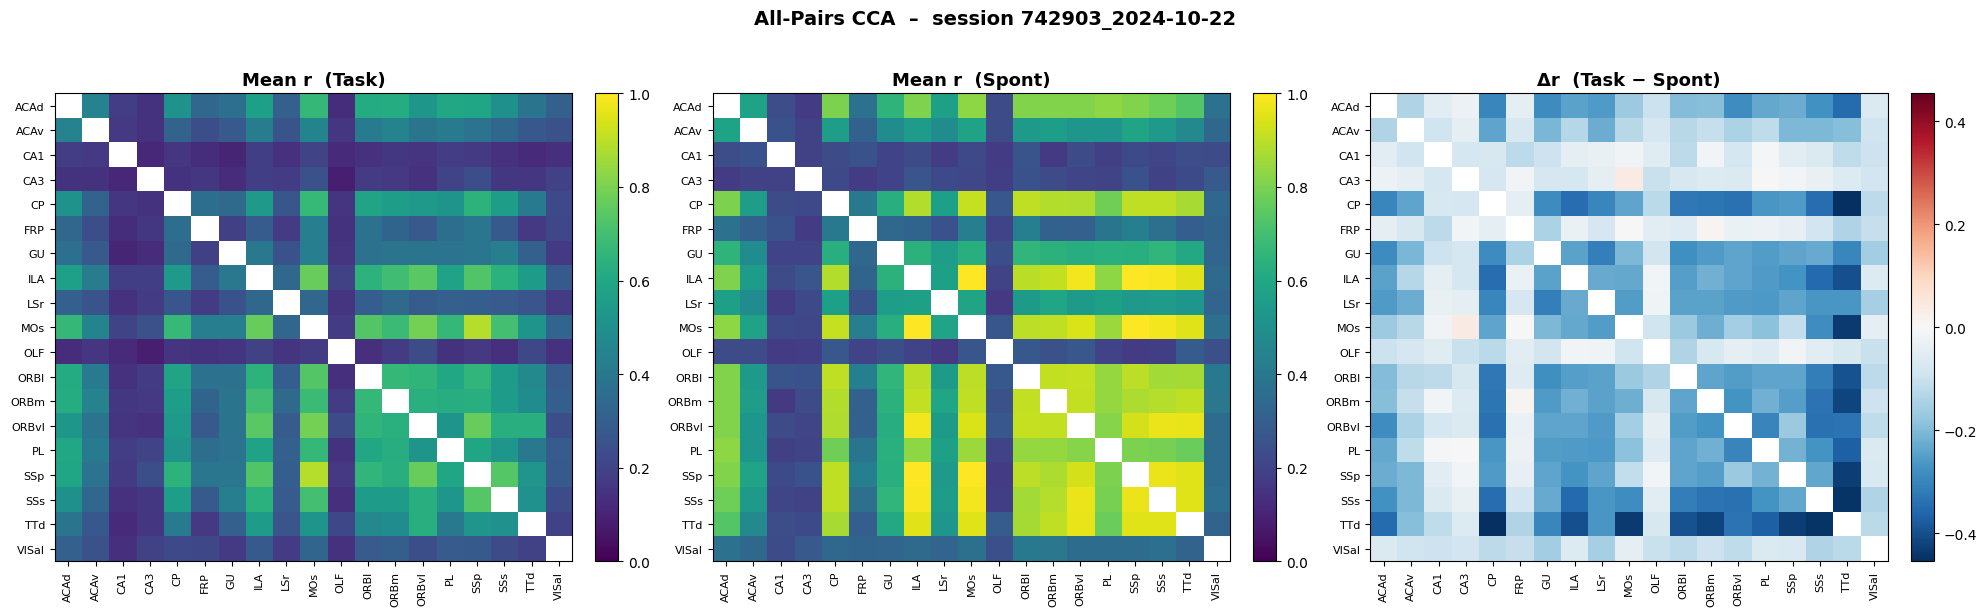

In [53]:
# ── Heatmaps: mean canonical correlation (task & spont) for all pairs ──────────
def make_symmetric_matrix(df, value_col, structs):
    """Fill a symmetric N×N matrix from pairwise summary_df."""
    n = len(structs)
    idx = {s: i for i, s in enumerate(structs)}
    mat = np.full((n, n), np.nan)
    for _, row in df.iterrows():
        i, j = idx[row['struct_A']], idx[row['struct_B']]
        mat[i, j] = mat[j, i] = row[value_col]
    return mat

structs_sorted = sorted(qualified_structures)
mat_task  = make_symmetric_matrix(summary_df, 'mean_r_task',  structs_sorted)
mat_spont = make_symmetric_matrix(summary_df, 'mean_r_spont', structs_sorted)
mat_delta = make_symmetric_matrix(summary_df, 'delta_r_task_spont', structs_sorted)

fig, axes = plt.subplots(1, 3, figsize=(20, 6))
cmap_r     = 'viridis'
cmap_delta = 'RdBu_r'

for ax, mat, title, cmap in [
    (axes[0], mat_task,  'Mean r  (Task)',    cmap_r),
    (axes[1], mat_spont, 'Mean r  (Spont)',   cmap_r),
    (axes[2], mat_delta, 'Δr  (Task − Spont)', cmap_delta),
]:
    vmax = np.nanmax(np.abs(mat)) if ax is axes[2] else 1.0#np.nanmax(mat)
    vmin = -vmax if ax is axes[2] else 0
    im = ax.imshow(mat, vmin=vmin, vmax=vmax, cmap=cmap, aspect='auto')
    ax.set_xticks(range(len(structs_sorted)))
    ax.set_yticks(range(len(structs_sorted)))
    ax.set_xticklabels(structs_sorted, rotation=90, fontsize=8)
    ax.set_yticklabels(structs_sorted, fontsize=8)
    ax.set_title(title, fontsize=13, fontweight='bold')
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

plt.suptitle(f'All-Pairs CCA  –  session {session_id}', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


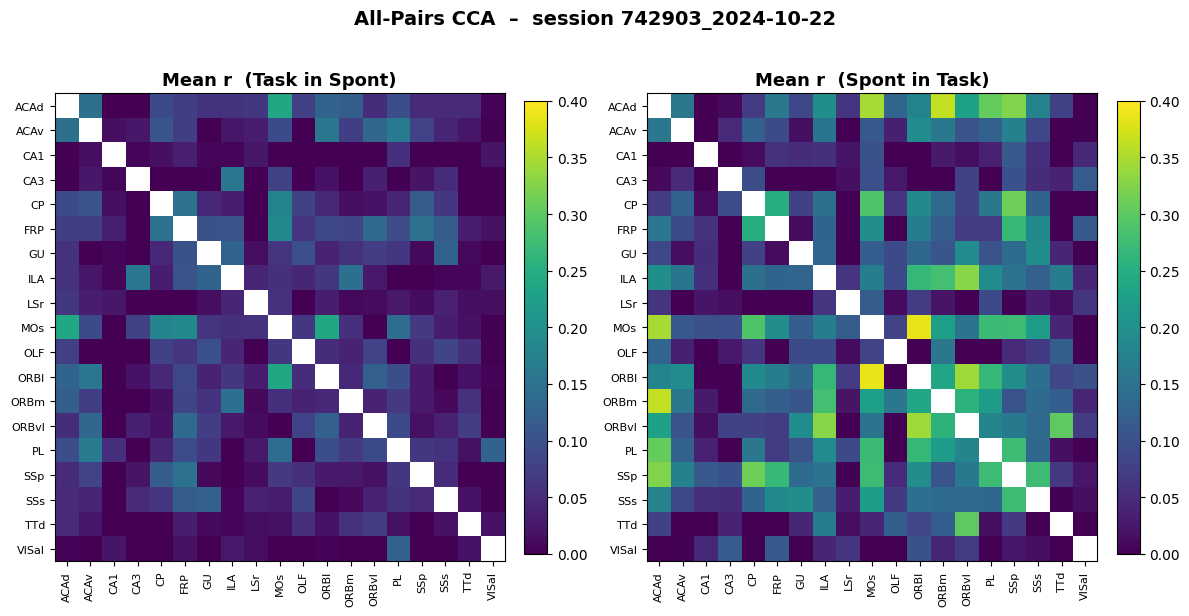

In [52]:
structs_sorted = sorted(qualified_structures)
mat_task  = make_symmetric_matrix(summary_df, 'mean_r_task_in_spont',  structs_sorted)
mat_spont = make_symmetric_matrix(summary_df, 'mean_r_spont_in_task', structs_sorted)
# mat_delta = make_symmetric_matrix(summary_df, 'delta_r_task_spont', structs_sorted)

fig, axes = plt.subplots(1, 2, figsize=(12, 6))
cmap_r     = 'viridis'
cmap_delta = 'RdBu_r'

for ax, mat, title, cmap in [
    (axes[0], mat_task,  'Mean r  (Task in Spont)',    cmap_r),
    (axes[1], mat_spont, 'Mean r  (Spont in Task)',   cmap_r),
    # (axes[2], mat_delta, 'Δr  (Task − Spont)', cmap_delta),
]:
    vmax = 0.4#np.nanmax(mat)
    vmin = 0
    im = ax.imshow(mat, vmin=vmin, vmax=vmax, cmap=cmap, aspect='auto')
    ax.set_xticks(range(len(structs_sorted)))
    ax.set_yticks(range(len(structs_sorted)))
    ax.set_xticklabels(structs_sorted, rotation=90, fontsize=8)
    ax.set_yticklabels(structs_sorted, fontsize=8)
    ax.set_title(title, fontsize=13, fontweight='bold')
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

plt.suptitle(f'All-Pairs CCA  –  session {session_id}', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

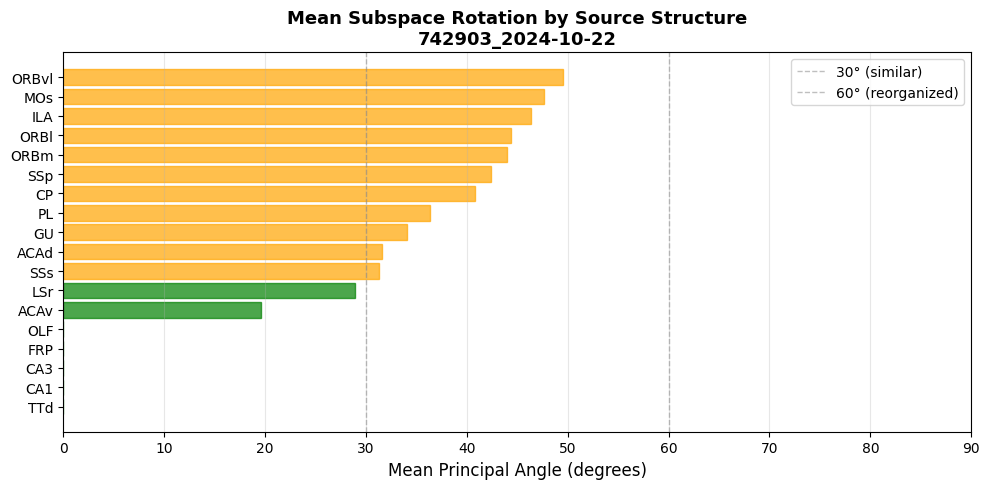


Mean principal angles by structure:
struct_A  mean_angle_A_deg
     TTd      2.561321e-07
     CA1      3.862576e-07
     CA3      4.278877e-07
     FRP      5.190302e-07
     OLF      5.386317e-07
    ACAv      1.963424e+01
     LSr      2.890154e+01
     SSs      3.129752e+01
    ACAd      3.163053e+01
      GU      3.404450e+01
      PL      3.631094e+01
      CP      4.080319e+01
     SSp      4.236350e+01
    ORBm      4.397292e+01
    ORBl      4.439353e+01
     ILA      4.638388e+01
     MOs      4.769770e+01
   ORBvl      4.951119e+01


In [50]:
# Group by struct_A and calculate mean principal angle across all pairs involving that structure
mean_angles_by_struct = (
    summary_df
    .groupby('struct_A')
    .agg(mean_angle_A_deg=('mean_angle_A_deg', 'mean'))
    .sort_values('mean_angle_A_deg', ascending=True)
    .reset_index()
)

# Create horizontal barplot
fig, ax = plt.subplots(figsize=(10, max(5, len(mean_angles_by_struct) * 0.25)))

y_pos = np.arange(len(mean_angles_by_struct))
bars = ax.barh(y_pos, mean_angles_by_struct['mean_angle_A_deg'], alpha=0.7, color='steelblue')

# Color code by angle threshold
for bar, angle in zip(bars, mean_angles_by_struct['mean_angle_A_deg']):
    if angle < 30:
        bar.set_color('green')
    elif angle < 60:
        bar.set_color('orange')
    else:
        bar.set_color('red')

ax.axvline(30, color='gray', linestyle='--', linewidth=1, alpha=0.5, label='30° (similar)')
ax.axvline(60, color='gray', linestyle='--', linewidth=1, alpha=0.5, label='60° (reorganized)')

ax.set_yticks(y_pos)
ax.set_yticklabels(mean_angles_by_struct['struct_A'], fontsize=10)
ax.set_xlabel('Mean Principal Angle (degrees)', fontsize=12)
ax.set_title(f'Mean Subspace Rotation by Source Structure\n{session_id}', 
             fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(axis='x', alpha=0.3)
ax.set_xlim([0, 90])

plt.tight_layout()
plt.show()

print(f"\nMean principal angles by structure:")
print(mean_angles_by_struct.to_string(index=False))

In [ ]:
# ── Save results ───────────────────────────────────────────────────────────────
import pathlib

output_dir = pathlib.Path('../results/cca')
output_dir.mkdir(parents=True, exist_ok=True)

# Component-level table (one row per pair × component)
component_path = output_dir / f'cca_components_{session_id}.parquet'
cca_results_df.to_parquet(component_path, index=False)

# Pair-level summary (one row per pair)
summary_path = output_dir / f'cca_summary_{session_id}.parquet'
summary_df.to_parquet(summary_path, index=False)

print(f"Saved component-level table → {component_path}")
print(f"  shape: {cca_results_df.shape}")
print(f"\nSaved pair-level summary    → {summary_path}")
print(f"  shape: {summary_df.shape}")


In [55]:
import polars as pl

session_table_path=r"\\allen\programs\mindscope\workgroups\dynamicrouting\Ethan\CO decoding results\session_table_v0.272.parquet"
session_table=pl.read_parquet(session_table_path)

dr_session_list=(
    session_table.filter(
    # pl.col('project')=="DynamicRouting",
    pl.col('is_production'),
    pl.col('is_annotated'),
    pl.col('issues')==[],
    # pl.col('is_good_behavior').eq(True),
    # pl.col('is_engaged').eq(True),
    )['session_id'].to_list()
    )

savepath=r"\\allen\programs\mindscope\workgroups\dynamicrouting\Ethan\CCA results"

In [56]:
import pathlib
import traceback

output_dir = pathlib.Path(savepath)
output_dir.mkdir(parents=True, exist_ok=True)


def run_session_cca(session_id, output_dir,
                    min_units=MIN_UNITS, var_thresh=VAR_THRESH,
                    max_cca_comps=MAX_CCA_COMPS, n_boot=N_BOOT,
                    time_before=0.5, time_after=0.01, binsize=0.5):
    """
    Run the full all-pairs CCA pipeline for one session and save results.

    Returns
    -------
    'saved'   – completed and files written
    'exists'  – output files already present (skipped)
    'no_spont'– session has no pre-task Spontaneous epoch (skipped)
    'error'   – unexpected exception (skipped)
    """
    component_path = output_dir / f'cca_components_{session_id}.parquet'
    summary_path   = output_dir / f'cca_summary_{session_id}.parquet'

    # ── Skip if already processed ──────────────────────────────────────────────
    if component_path.exists() and summary_path.exists():
        return 'exists'

    try:
        # ── Load session data ──────────────────────────────────────────────────
        session_info = npc_lims.get_session_info(session_id)
        trials       = data_utils.load_trials_or_units(session_info, 'trials',  version='0.0.272')
        units        = data_utils.load_trials_or_units(session_info, 'units',   version='0.0.272')
        epochs       = pd.read_parquet(
            npc_lims.get_cache_path(nwb_component='epochs', session_id=session_id, version='0.0.272')
        )

        # ── Check for pre-task Spontaneous epoch ───────────────────────────────
        task_rows = epochs.query('script_name=="DynamicRouting1"')
        if len(task_rows) == 0:
            return 'no_spont'
        task_index = task_rows.index[0]
        spont_epochs = epochs.query('script_name=="Spontaneous" and id<@task_index')
        if len(spont_epochs) == 0:
            return 'no_spont'

        # ── Filter units ───────────────────────────────────────────────────────
        units_filtered = units.query(
            'presence_ratio>=0.7 and '
            'isi_violations_ratio<=0.5 and '
            'amplitude_cutoff<=0.1 and '
            'activity_drift<=0.2 and '
            'firing_rate>=0.5 and '
            '~structure.isna() and ~location.isna()'
        ).sort_values(['electrode_group_name', 'peak_channel', 'unit_id'])

        if len(units_filtered) == 0:
            return 'no_spont'  # reuse label for "nothing to analyse"

        # ── Build task neural tensor ───────────────────────────────────────────
        trial_da = spike_utils.make_neuron_time_trials_tensor(
            units_filtered, trials, time_before, time_after, binsize
        )

        # ── Build spontaneous neural tensor ────────────────────────────────────
        import lazynwb
        nwb_path = 's3://aind-scratch-data/dynamic-routing/cache/nwb/v0.0.272/{sid}.nwb'
        rewards = lazynwb.get_df(
            nwb_path.format(sid=session_id),
            'processing/behavior/rewards',
            as_polars=False
        )

        spont_trials_dict = {'start_time': [], 'epoch_idx': [], 'epoch_name': [], 'is_rewarded': []}
        for rr, row in spont_epochs.iterrows():
            spont_start, spont_end = row['start_time'], row['stop_time']
            sampleITIs     = generate_DR_ITI(n_samples=1000, is_templeton=False)
            cum_ITIs       = np.cumsum(sampleITIs)
            valid_starts   = spont_start + cum_ITIs[cum_ITIs + spont_start < spont_end]
            is_rew         = np.zeros(len(valid_starts), dtype=bool)

            reward_times = rewards.query(
                'timestamps>=@spont_start and timestamps<=@spont_end'
            )['timestamps'].to_numpy()
            if len(reward_times) > 0:
                for rt in reward_times:
                    keep = np.abs(valid_starts - rt) > 5.5
                    valid_starts, is_rew = valid_starts[keep], is_rew[keep]
                valid_starts = np.concatenate([valid_starts, reward_times])
                is_rew       = np.concatenate([is_rew, np.ones(len(reward_times), dtype=bool)])

            spont_trials_dict['start_time'].append(valid_starts)
            spont_trials_dict['epoch_idx'].append(np.repeat(rr,               len(valid_starts)))
            spont_trials_dict['epoch_name'].append(np.repeat(row['script_name'], len(valid_starts)))
            spont_trials_dict['is_rewarded'].append(is_rew)

        for k in spont_trials_dict:
            spont_trials_dict[k] = np.concatenate(spont_trials_dict[k])
        spont_trials_df = (
            pd.DataFrame(spont_trials_dict)
            .sort_values('start_time')
            .reset_index(drop=True)
        )
        if len(spont_trials_df) == 0:
            return 'no_spont'

        spont_trial_da = spike_utils.make_neuron_time_trials_tensor(
            units_filtered, spont_trials_df, time_before, time_after, binsize,
            event_name='start_time'
        )

        # ── Per-structure PCA ──────────────────────────────────────────────────
        unit_counts         = units_filtered.groupby('structure')['unit_id'].nunique()
        qualified_structures = sorted(unit_counts[unit_counts >= min_units].index.tolist())
        if len(qualified_structures) < 2:
            return 'no_spont'

        struct_data = {}
        for struct in qualified_structures:
            uid     = units_filtered[units_filtered['structure'] == struct]['unit_id'].unique()
            A_task  = trial_da.sel(unit_id=uid).data[:, 0, :].T
            A_spont = spont_trial_da.sel(unit_id=uid).data[:, 0, :].T
            A_pool  = np.vstack([A_task, A_spont])
            scaler  = StandardScaler().fit(A_pool)
            A_pool_z = scaler.transform(A_pool)
            A_task_z  = A_pool_z[:A_task.shape[0]]
            A_spont_z = A_pool_z[A_task.shape[0]:]
            pca, n_pc, _ = pca_fit_keep(A_pool_z, var_thresh=var_thresh)
            struct_data[struct] = {
                'task_z'   : A_task_z,  'spont_z'  : A_spont_z,
                'pca'      : pca,       'n_pc'      : n_pc,
                'n_units'  : len(uid),
                'task_pca' : pca.transform(A_task_z),
                'spont_pca': pca.transform(A_spont_z),
            }

        # ── All-pairs CCA ──────────────────────────────────────────────────────
        all_records = []
        for sA, sB in combinations(qualified_structures, 2):
            pair_records = run_cca_pair(struct_data[sA], struct_data[sB],
                                        max_cca_comps=max_cca_comps, n_boot=n_boot)
            for rec in pair_records:
                rec['struct_A'] = sA
                rec['struct_B'] = sB
            all_records.extend(pair_records)

        if len(all_records) == 0:
            return 'no_spont'

        # ── Build DataFrames ───────────────────────────────────────────────────
        col_order = [
            'session_id', 'struct_A', 'struct_B',
            'n_units_A', 'n_units_B', 'n_pca_A', 'n_pca_B',
            'n_task_trials', 'n_spont_trials', 'n_cca_comps', 'component',
            'r_task', 'r_task_ci_lo', 'r_task_ci_hi',
            'r_spont', 'r_spont_ci_lo', 'r_spont_ci_hi',
            'r_task_in_spont', 'r_spont_in_task',
            'angle_A_deg', 'angle_B_deg',
        ]
        cca_df = (
            pd.DataFrame(all_records)
            .assign(session_id=session_id)
            [col_order]
            .sort_values(['struct_A', 'struct_B', 'component'])
            .reset_index(drop=True)
        )
        sum_df = (
            cca_df
            .groupby(['session_id', 'struct_A', 'struct_B', 'n_units_A', 'n_units_B',
                      'n_pca_A', 'n_pca_B', 'n_task_trials', 'n_spont_trials', 'n_cca_comps'],
                     sort=False)
            .agg(
                mean_r_task          =('r_task',          'mean'),
                mean_r_spont         =('r_spont',         'mean'),
                mean_r_task_in_spont =('r_task_in_spont', 'mean'),
                mean_r_spont_in_task =('r_spont_in_task', 'mean'),
                mean_angle_A_deg     =('angle_A_deg',     'mean'),
                mean_angle_B_deg     =('angle_B_deg',     'mean'),
                r_task_comp1         =('r_task',          'first'),
                r_spont_comp1        =('r_spont',         'first'),
            )
            .assign(delta_r_task_spont=lambda d: d['mean_r_task'] - d['mean_r_spont'])
            .reset_index()
        )

        # ── Save ───────────────────────────────────────────────────────────────
        cca_df.to_parquet(component_path, index=False)
        sum_df.to_parquet(summary_path,   index=False)
        return 'saved'

    except Exception:
        traceback.print_exc()
        return 'error'


# ── Run over all sessions ──────────────────────────────────────────────────────
status_counts = {'saved': 0, 'exists': 0, 'no_spont': 0, 'error': 0}
t0 = time.time()

for s_idx, sid in enumerate(dr_session_list):
    status = run_session_cca(sid, output_dir)
    status_counts[status] += 1
    tag = {'saved': '✓', 'exists': '–', 'no_spont': 'skip', 'error': 'ERR'}[status]
    print(f"[{s_idx+1:4d}/{len(dr_session_list)}]  {sid}  {tag}  "
          f"({time.time()-t0:.0f}s elapsed)")

print(f"\nDone.  {status_counts}")


620263_2022-07-26 cached trials loaded
620263_2022-07-26 cached units loaded
[   1/178]  620263_2022-07-26  skip  (24s elapsed)
620263_2022-07-27 cached trials loaded
620263_2022-07-27 cached units loaded
[   2/178]  620263_2022-07-27  skip  (29s elapsed)
620264_2022-08-02 cached trials loaded
620264_2022-08-02 cached units loaded
[   3/178]  620264_2022-08-02  skip  (38s elapsed)
626791_2022-08-15 cached trials loaded
626791_2022-08-15 cached units loaded
[   4/178]  626791_2022-08-15  skip  (50s elapsed)
626791_2022-08-16 cached trials loaded
626791_2022-08-16 cached units loaded
[   5/178]  626791_2022-08-16  skip  (55s elapsed)
626791_2022-08-17 cached trials loaded
626791_2022-08-17 cached units loaded
[   6/178]  626791_2022-08-17  skip  (65s elapsed)
628801_2022-09-19 cached trials loaded
628801_2022-09-19 cached units loaded
[   7/178]  628801_2022-09-19  skip  (78s elapsed)
636397_2022-09-26 cached trials loaded
636397_2022-09-26 cached units loaded
[   8/178]  636397_2022-09-

c:\Anaconda3\envs\dr_ibl_analysis\Lib\site-packages\sklearn\cross_decomposition\_pls.py:113: ConvergenceWarning: Maximum number of iterations reached
  warnings.warn("Maximum number of iterations reached", ConvergenceWarning)


[  38/178]  668759_2023-07-13  ✓  (478s elapsed)
670181_2023-07-18 cached trials loaded
670181_2023-07-18 cached units loaded


c:\Anaconda3\envs\dr_ibl_analysis\Lib\site-packages\sklearn\cross_decomposition\_pls.py:113: ConvergenceWarning: Maximum number of iterations reached
  warnings.warn("Maximum number of iterations reached", ConvergenceWarning)


[  39/178]  670181_2023-07-18  ✓  (564s elapsed)
670180_2023-07-26 cached trials loaded
670180_2023-07-26 cached units loaded


...

[ 175/178]  759434_2025-02-04  ✓  (12351s elapsed)
759434_2025-02-05 cached trials loaded
759434_2025-02-05 cached units loaded
[ 176/178]  759434_2025-02-05  ✓  (12378s elapsed)
759434_2025-02-06 cached trials loaded
759434_2025-02-06 cached units loaded


c:\Anaconda3\envs\dr_ibl_analysis\Lib\site-packages\sklearn\cross_decomposition\_pls.py:113: ConvergenceWarning: Maximum number of iterations reached
  warnings.warn("Maximum number of iterations reached", ConvergenceWarning)


[ 177/178]  759434_2025-02-06  ✓  (12409s elapsed)
759434_2025-02-07 cached trials loaded
759434_2025-02-07 cached units loaded


c:\Anaconda3\envs\dr_ibl_analysis\Lib\site-packages\sklearn\cross_decomposition\_pls.py:113: ConvergenceWarning: Maximum number of iterations reached
  warnings.warn("Maximum number of iterations reached", ConvergenceWarning)
c:\Anaconda3\envs\dr_ibl_analysis\Lib\site-packages\sklearn\cross_decomposition\_pls.py:113: ConvergenceWarning: Maximum number of iterations reached
  warnings.warn("Maximum number of iterations reached", ConvergenceWarning)
c:\Anaconda3\envs\dr_ibl_analysis\Lib\site-packages\sklearn\cross_decomposition\_pls.py:113: ConvergenceWarning: Maximum number of iterations reached
  warnings.warn("Maximum number of iterations reached", ConvergenceWarning)
c:\Anaconda3\envs\dr_ibl_analysis\Lib\site-packages\sklearn\cross_decomposition\_pls.py:113: ConvergenceWarning: Maximum number of iterations reached
  warnings.warn("Maximum number of iterations reached", ConvergenceWarning)


[ 178/178]  759434_2025-02-07  ✓  (12475s elapsed)

Done.  {'saved': 140, 'exists': 0, 'no_spont': 38, 'error': 0}


## 13. Cross-Session Average Heatmaps

Load all saved summary files, compute per-structure-pair averages across sessions, and visualise.


In [68]:
all_performance=pl.scan_parquet('s3://aind-scratch-data/dynamic-routing/cache/nwb_components/v0.0.272/consolidated/performance.parquet').collect()

dr_session_performance={
    'session_id':[],
    'session_table_is_good_behavior':[],
    'performance_is_good_behavior':[],
    '_2vis_2aud_is_good_behavior':[],
}
for sel_session in all_performance['session_id'].unique():

    temp_project=session_table.filter(pl.col('session_id')==sel_session)['project']
    if len(temp_project)==0 or temp_project[0] not in ["DynamicRouting"]:
        continue

    session_performance=all_performance.filter(pl.col('session_id')==sel_session)
    n_passing_blocks=np.nansum(session_performance['cross_modality_dprime'].to_numpy()>=1.0)
    n_engaged_blocks=np.nansum(session_performance['n_contingent_rewards'].to_numpy()>10)

    n_vis_passing_blocks=np.nansum(session_performance.filter(pl.col('rewarded_modality')=='vis')['cross_modality_dprime'].to_numpy()>=1.0)
    n_aud_passing_blocks=np.nansum(session_performance.filter(pl.col('rewarded_modality')=='aud')['cross_modality_dprime'].to_numpy()>=1.0)

    dr_session_performance['session_id'].append(sel_session)

    dr_session_performance['session_table_is_good_behavior'].append(session_table.filter(pl.col('session_id')==sel_session)['is_good_behavior'][0])
    if n_passing_blocks>4 and n_engaged_blocks>4:
        dr_session_performance['performance_is_good_behavior'].append(True)
    else:
        dr_session_performance['performance_is_good_behavior'].append(False)

    if n_vis_passing_blocks>=2 and n_aud_passing_blocks>=2:
        dr_session_performance['_2vis_2aud_is_good_behavior'].append(True)
    else:
        dr_session_performance['_2vis_2aud_is_good_behavior'].append(False)

dr_session_performance=pl.DataFrame(dr_session_performance)
dr_session_performance

session_id,session_table_is_good_behavior,performance_is_good_behavior,_2vis_2aud_is_good_behavior
str,bool,bool,bool
"""702131_2024-02-26""",true,true,true
"""666986_2023-08-14""",true,true,true
"""742903_2024-10-24""",true,true,true
"""703333_2024-04-10""",false,false,false
"""706401_2024-04-23""",true,true,true
…,…,…,…
"""714748_2024-06-26""",true,true,true
"""712141_2024-06-13""",false,false,true
"""743199_2024-12-06""",true,true,true


In [69]:
dr_session_list=dr_session_performance.to_pandas().query('_2vis_2aud_is_good_behavior==True')['session_id'].values

In [70]:
import pathlib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ── Load all saved summary files ───────────────────────────────────────────────
results_dir = pathlib.Path(savepath)
summary_files = sorted(results_dir.glob('cca_summary_*.parquet'))

print(f"Found {len(summary_files)} session summary files in {results_dir}")

all_summaries = []
for f in summary_files:
    try:
        all_summaries.append(pd.read_parquet(f))
    except Exception as e:
        print(f"  Could not load {f.name}: {e}")

all_summaries_df = pd.concat(all_summaries, ignore_index=True)

all_summaries_df=all_summaries_df.query('session_id in @dr_session_list')

print(f"Total rows loaded: {len(all_summaries_df)}")
print(f"Sessions: {all_summaries_df['session_id'].nunique()}")
print(f"Unique structure pairs: {len(all_summaries_df.groupby(['struct_A','struct_B']))}")


Found 140 session summary files in \\allen\programs\mindscope\workgroups\dynamicrouting\Ethan\CCA results
Total rows loaded: 13833
Sessions: 82
Unique structure pairs: 4718


In [74]:
all_summaries_df.columns

Index(['session_id', 'struct_A', 'struct_B', 'n_units_A', 'n_units_B',
       'n_pca_A', 'n_pca_B', 'n_task_trials', 'n_spont_trials', 'n_cca_comps',
       'mean_r_task', 'mean_r_spont', 'mean_r_task_in_spont',
       'mean_r_spont_in_task', 'mean_angle_A_deg', 'mean_angle_B_deg',
       'r_task_comp1', 'r_spont_comp1', 'delta_r_task_spont'],
      dtype='object')

In [75]:
# ── Cross-session averages per structure pair ──────────────────────────────────
# Keep both (A,B) and (B,A) orientations so the matrix is symmetric.
# For angle metrics we use struct_A's angle only (as established above).

metrics = ['mean_r_task', 'mean_r_spont', 'mean_r_task_in_spont',
           'mean_r_spont_in_task', 'delta_r_task_spont', 'mean_angle_A_deg',
           'mean_angle_B_deg']

# Stack both directions so every pair appears twice (once per orientation)
fwd = all_summaries_df[['session_id', 'struct_A', 'struct_B'] + metrics].copy()
rev = all_summaries_df[['session_id', 'struct_B', 'struct_A'] + metrics].copy()
rev.columns = ['session_id', 'struct_A', 'struct_B'] + metrics

both = pd.concat([fwd, rev], ignore_index=True)

# Average over sessions for each (struct_A, struct_B) pair
cross_session_avg = (
    both
    .groupby(['struct_A', 'struct_B'], sort=True)
    .agg(
        **{m: (m, 'mean') for m in metrics},
        n_sessions=('session_id', 'nunique'),
    )
    .reset_index()
)

# Minimum sessions threshold for display
MIN_SESSIONS = 3
cross_session_avg_filt = cross_session_avg[cross_session_avg['n_sessions'] >= MIN_SESSIONS]

# All structures appearing in filtered data
all_structs = sorted(set(cross_session_avg_filt['struct_A']) | set(cross_session_avg_filt['struct_B']))
print(f"Structures with >= {MIN_SESSIONS} sessions in at least one pair: {len(all_structs)}")
print(f"Pairs retained: {len(cross_session_avg_filt)}")
cross_session_avg_filt.head(10)


Structures with >= 3 sessions in at least one pair: 112
Pairs retained: 3218


,struct_A,struct_B,mean_r_task,mean_r_spont,mean_r_task_in_spont,mean_r_spont_in_task,delta_r_task_spont,mean_angle_A_deg,mean_angle_B_deg,n_sessions
0,ACAd,ACAv,0.506877,0.699813,0.075870,0.187545,-0.192935,39.542723,39.421065,22
6,ACAd,AON,0.346602,0.575446,0.041551,0.076367,-0.228844,32.803730,32.461645,5
7,ACAd,APN,0.344143,0.451717,0.115850,0.215602,-0.107574,11.883217,11.411585,7
8,ACAd,AUDd,0.348059,0.556551,0.076361,0.005222,-0.208492,28.863443,28.745921,3
9,ACAd,AUDp,0.357969,0.532608,0.043927,0.147783,-0.174639,29.806243,26.614024,3
11,ACAd,AUDv,0.254271,0.409441,0.075554,0.066543,-0.155171,16.281338,15.013106,3
13,ACAd,CA1,0.357247,0.557989,0.027782,0.082664,-0.200742,29.383169,30.363911,18
15,ACAd,CA3,0.264540,0.427513,0.037614,0.070915,-0.162973,20.619145,21.999550,8
17,ACAd,CP,0.417440,0.603819,0.066018,0.150852,-0.186379,29.721384,28.739040,17
18,ACAd,DG,0.209854,0.348634,0.028170,0.059823,-0.138779,9.010700,9.518382,9


Structures after coverage filter (40%): 24 / 112  →  ['ACAd', 'ACAv', 'CA1', 'CA3', 'CP', 'DG', 'FRP', 'MB', 'MOp', 'MOs', 'MRN', 'OLF', 'ORBl', 'PL', 'RSPagl', 'RSPd', 'RSPv', 'SCig', 'SCiw', 'SSp', 'SSs', 'SUB', 'VISp', 'ZI']


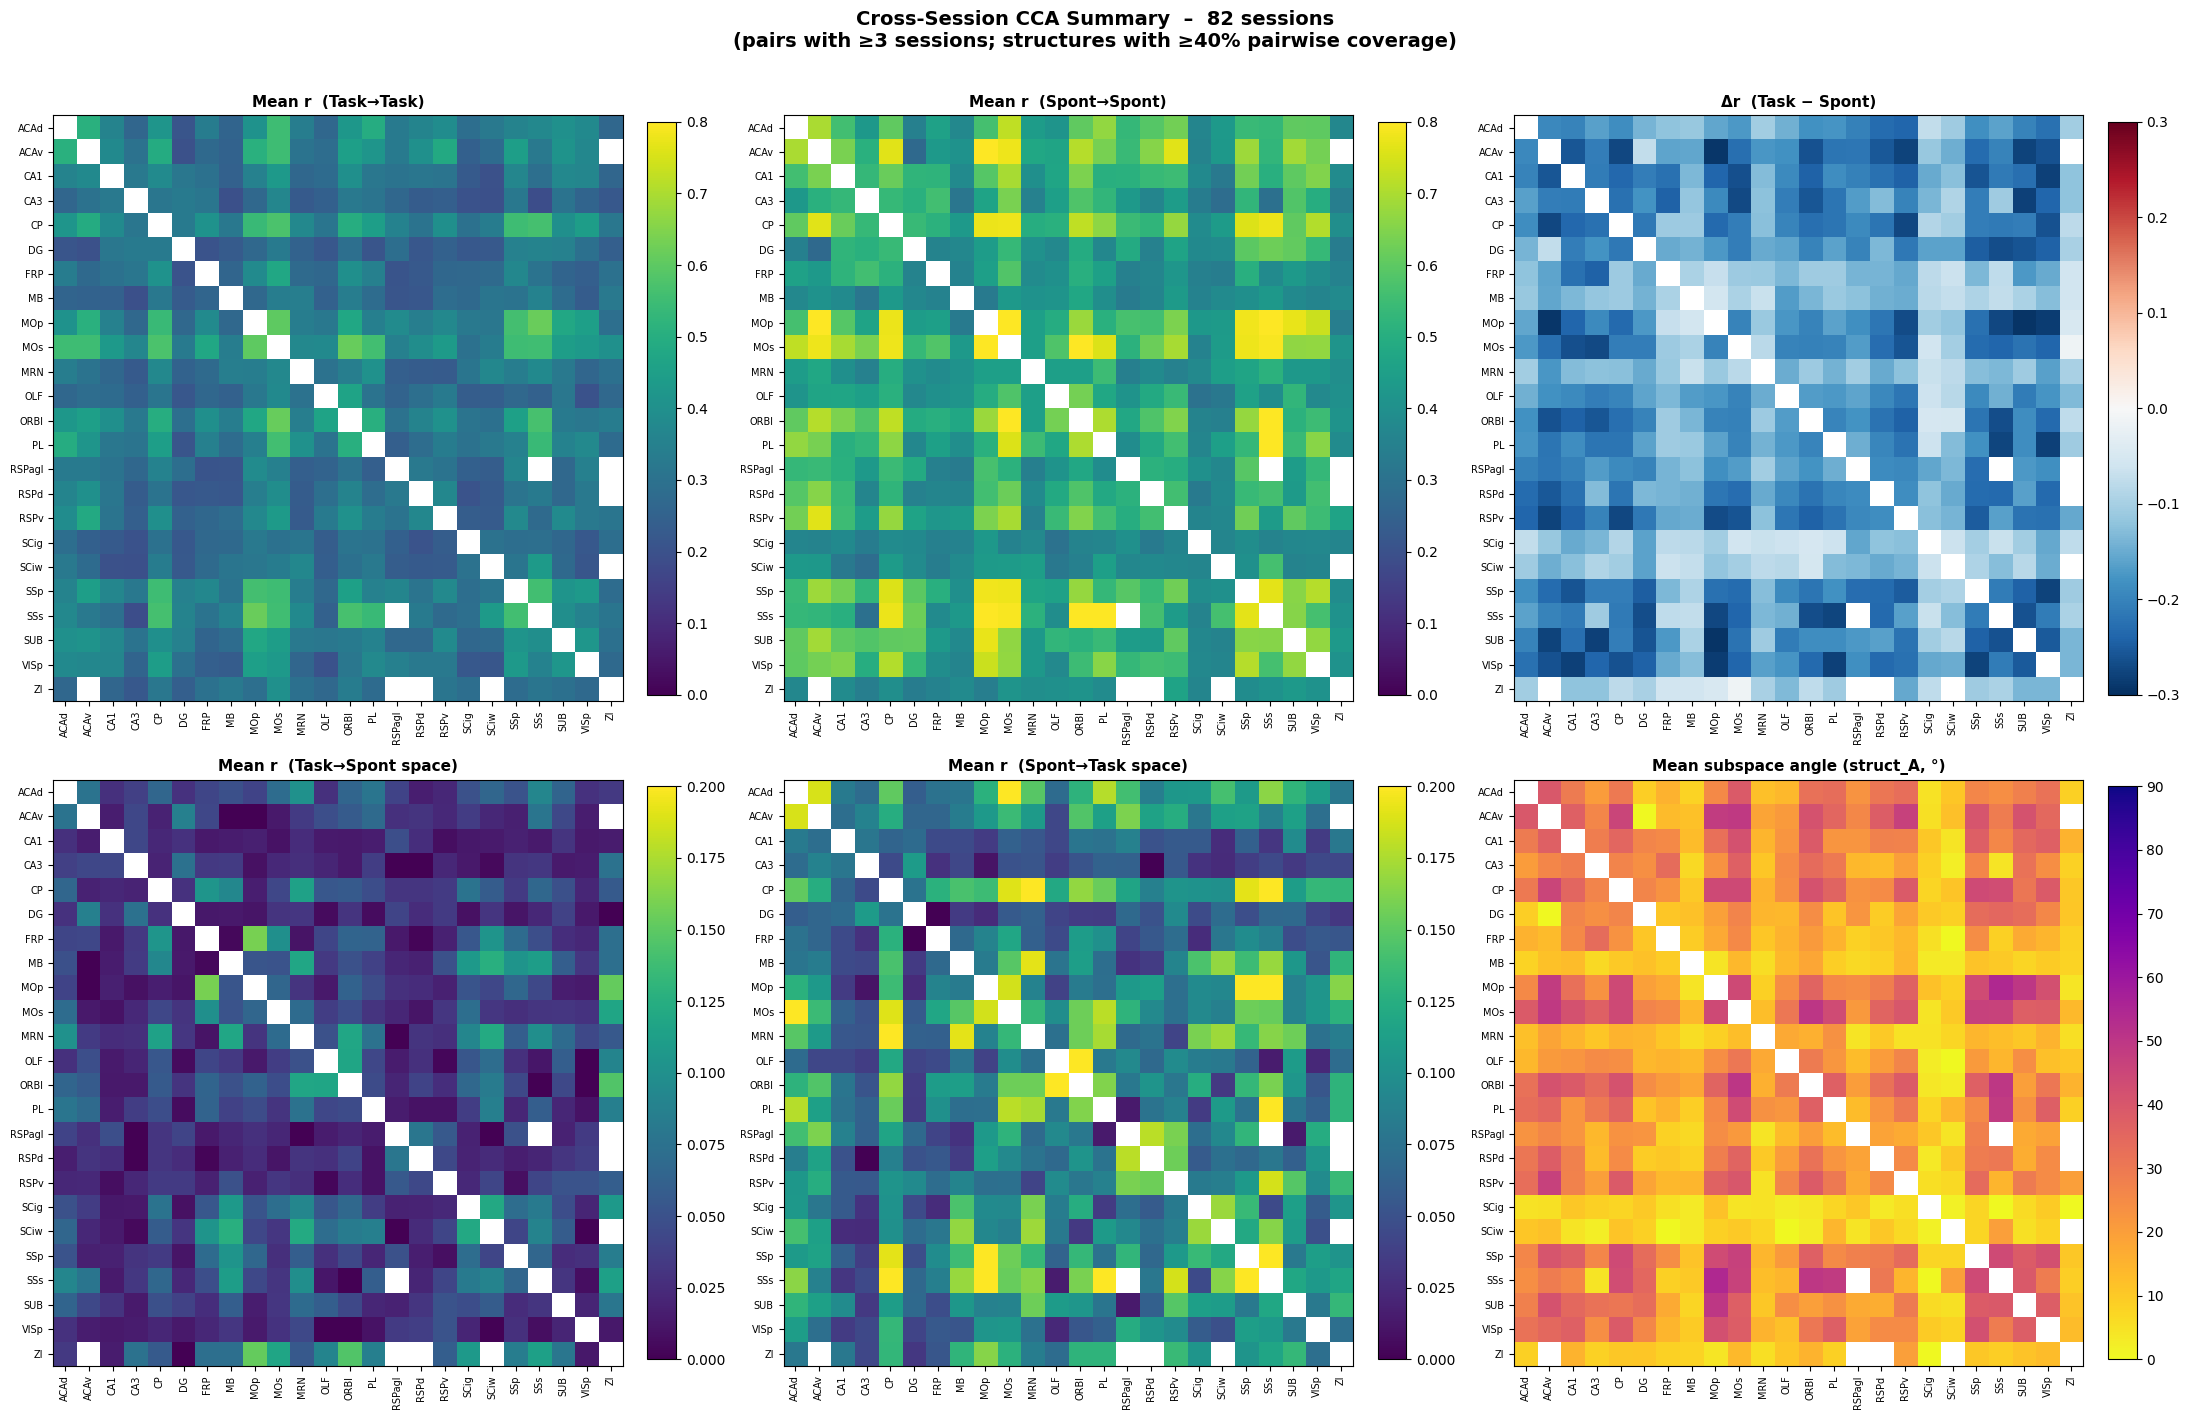

In [78]:
def build_matrix(df, value_col, structs):
    """Build a symmetric N×N matrix from a long-format pairwise DataFrame."""
    n = len(structs)
    idx = {s: i for i, s in enumerate(structs)}
    mat = np.full((n, n), np.nan)
    for _, row in df.iterrows():
        if row['struct_A'] in idx and row['struct_B'] in idx:
            i, j = idx[row['struct_A']], idx[row['struct_B']]
            mat[i, j] = row[value_col]
    return mat


def filter_structs_by_coverage(df, structs, coverage_thresh=0.70):
    """
    Iteratively drop structures that have valid pairs with fewer than
    `coverage_thresh` of the other currently-included structures.
    Converges when no more structures are removed.
    """
    structs = list(structs)
    while True:
        n = len(structs)
        if n <= 1:
            break
        pair_counts = (
            df[df['struct_A'].isin(structs) & df['struct_B'].isin(structs)]
            .groupby('struct_A')['struct_B']
            .count()
        )
        keep = [s for s in structs if pair_counts.get(s, 0) / (n - 1) >= coverage_thresh]
        if len(keep) == len(structs):
            break
        structs = keep
    return structs


def plot_heatmap(ax, mat, structs, title, vmin, vmax, cmap, fig,
                 show_values=False, n_sessions_mat=None):
    im = ax.imshow(mat, vmin=vmin, vmax=vmax, cmap=cmap, aspect='auto')
    ax.set_xticks(range(len(structs)))
    ax.set_yticks(range(len(structs)))
    ax.set_xticklabels(structs, rotation=90, fontsize=7)
    ax.set_yticklabels(structs, fontsize=7)
    ax.set_title(title, fontsize=11, fontweight='bold')
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    if show_values and n_sessions_mat is not None:
        for i in range(len(structs)):
            for j in range(len(structs)):
                v = n_sessions_mat[i, j]
                if not np.isnan(v):
                    ax.text(j, i, f'{int(v)}', ha='center', va='center',
                            fontsize=5, color='white')


# ── Filter to well-covered structures ─────────────────────────────────────────
COVERAGE_THRESH = 0.40   # each struct must have data for ≥70 % of others
plot_structs = filter_structs_by_coverage(
    cross_session_avg_filt, all_structs, COVERAGE_THRESH
)
print(f"Structures after coverage filter ({COVERAGE_THRESH:.0%}): "
      f"{len(plot_structs)} / {len(all_structs)}  →  {plot_structs}")

# ── Build matrices ─────────────────────────────────────────────────────────────
mat_r_task     = build_matrix(cross_session_avg_filt, 'mean_r_task',          plot_structs)
mat_r_spont    = build_matrix(cross_session_avg_filt, 'mean_r_spont',         plot_structs)
mat_delta      = build_matrix(cross_session_avg_filt, 'delta_r_task_spont',   plot_structs)
mat_task_spont = build_matrix(cross_session_avg_filt, 'mean_r_task_in_spont', plot_structs)
mat_spont_task = build_matrix(cross_session_avg_filt, 'mean_r_spont_in_task', plot_structs)
mat_angle      = build_matrix(cross_session_avg_filt, 'mean_angle_A_deg',     plot_structs)
mat_n          = build_matrix(cross_session_avg_filt, 'n_sessions',           plot_structs)

n_sessions_total = all_summaries_df['session_id'].nunique()

# ── Main heatmap figure ────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(22, 14))
axes = axes.flatten()

plot_heatmap(axes[0], mat_r_task,     plot_structs, 'Mean r  (Task→Task)',              0,    0.8,    'viridis',  fig)
plot_heatmap(axes[1], mat_r_spont,    plot_structs, 'Mean r  (Spont→Spont)',             0,    0.8,    'viridis',  fig)
plot_heatmap(axes[2], mat_delta,      plot_structs, 'Δr  (Task − Spont)',               -0.3,  0.3,  'RdBu_r',   fig)
plot_heatmap(axes[3], mat_task_spont, plot_structs, 'Mean r  (Task→Spont space)',        0,    0.2,    'viridis',  fig)
plot_heatmap(axes[4], mat_spont_task, plot_structs, 'Mean r  (Spont→Task space)',        0,    0.2,    'viridis',  fig)
plot_heatmap(axes[5], mat_angle,      plot_structs, 'Mean subspace angle (struct_A, °)', 0,   90,   'plasma_r', fig)

plt.suptitle(
    f'Cross-Session CCA Summary  –  {n_sessions_total} sessions\n'
    f'(pairs with ≥{MIN_SESSIONS} sessions; structures with ≥{COVERAGE_THRESH:.0%} pairwise coverage)',
    fontsize=14, fontweight='bold', y=1.01
)
plt.tight_layout()
plt.show()
